## Implementing TIGER: Generative Retrieval for Sequential Recommendation

In [ ]:
!nvidia-smi

Thu May 28 22:53:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

You should see a line mentioning **Tesla T4** and about **15 GB** of memory. If you see a different GPU (e.g., K80), change the runtime type.

---

## Step 1 — One-time setup: upload the dataset to your Drive

Do this **once**, from your own machine, *not* inside Colab:

1. Download the Amazon Toys & Games data. The two files you need are:
   - `Toys_and_Games_5.json.gz` (or `Toys_and_Games.csv` — the reviews/ratings file with `userId, itemId, rating, timestamp`)
   - `meta_Toys_and_Games.json.gz` (item metadata: `title`, `description`, `categories`, `brand`, `price`)

   Sources:
   - 2014 version (the one the TIGER paper uses): https://jmcauley.ucsd.edu/data/amazon/
   - 2023 version (larger, cleaner): https://amazon-reviews-2023.github.io/

   Either works. The 2014 5-core version is smaller and matches the paper exactly.

2. In your Google Drive (drive.google.com), create this folder structure:

   ```
   MyDrive/
   └── tiger_assignment/
       ├── data/               ← put the two dataset files here
       ├── embeddings/         ← will hold cached Sentence-T5 embeddings (we'll write to this)
       └── checkpoints/        ← will hold RQ-VAE and Transformer checkpoints (we'll write to this)
   ```

3. Upload the two dataset files into `MyDrive/tiger_assignment/data/`. You can drag-and-drop them in the Drive web UI.

You only do this once. From now on, every Colab session just mounts Drive and reads from `data/`.

---

## Step 2 — Mount Drive in Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


A pop-up asks you to authorize access — sign in with the same Google account that owns the Drive folder.

After it succeeds, your Drive is mounted at `/content/drive/MyDrive/`. Let's define the project paths we'll use throughout the assignment:

In [ ]:
import os

# Root of this project on Drive — everything persists here
PROJECT_DIR = '/content/drive/MyDrive/tiger_assignment'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
EMB_DIR = os.path.join(PROJECT_DIR, 'embeddings')
CKPT_DIR = os.path.join(PROJECT_DIR, 'checkpoints')

# Make sure the subdirectories exist (no-op if they already do)
os.makedirs(EMB_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# Sanity check: list what's in data/
print('Files in data/:')
for f in sorted(os.listdir(DATA_DIR)):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

Files in data/:
  Toys_and_Games_5.json.gz  (415.3 MB)
  meta_Toys_and_Games.json.gz  (145.0 MB)


You should see your two dataset files listed. If you see `FileNotFoundError`, double-check the folder path in Drive matches `tiger_assignment/data/`.

---

## Step 3 — Load the reviews/interactions file

The Amazon 2014 files are gzipped JSONL (one JSON object per line). We'll read them with pandas. If you're using the 2023 CSV version, the loading is even simpler — just `pd.read_csv(...)`.

**Do NOT copy the file to `/content/` first** — pandas can read directly from the Drive mount path. The file stays on Drive; only the parsed DataFrame lives in memory.

In [ ]:
import pandas as pd
import gzip, json

def load_jsonl_gz(path):
    """Load a gzipped JSONL file (Amazon 2014 format) into a DataFrame."""
    records = []
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

# Adjust the filename to match what you uploaded
reviews_path = os.path.join(DATA_DIR, 'Toys_and_Games_5.json.gz')
reviews = load_jsonl_gz(reviews_path)

# Amazon 2014 fields: reviewerID, asin, overall (rating), unixReviewTime, ...
# Rename to the schema used in the assignment spec
reviews = reviews.rename(columns={
    'reviewerID': 'userId',
    'asin': 'itemId',
    'overall': 'rating',
    'unixReviewTime': 'timestamp',
})[['userId', 'itemId', 'rating', 'timestamp']]

print(f'Loaded {len(reviews):,} reviews')
print(f'Unique users: {reviews.userId.nunique():,}')
print(f'Unique items: {reviews.itemId.nunique():,}')
reviews.head()

Loaded 2,252,771 reviews
Unique users: 1,342,911
Unique items: 327,698


,userId,itemId,rating,timestamp
0,AMEVO2LY6VEJA,0000191639,5.0,1388016000
1,A3C9CSW3TJITGT,0005069491,4.0,1377561600
2,A31POTIYCKSZ9G,0076561046,3.0,1404864000
3,A2GGHHME9B6W4O,0131358936,5.0,1382400000
4,A1FSLDH43ORWZP,0133642984,5.0,1374278400


## Phase 1: Data Preprocessing

In [ ]:
print(f"Starting interactions: {len(reviews):,}")

# We iterate because removing a user might drop an item's count below 5,
# and removing that item might drop another user's count below 5.
iteration = 1
while True:
    user_counts = reviews['userId'].value_counts()
    item_counts = reviews['itemId'].value_counts()

    valid_users = user_counts[user_counts >= 5].index
    valid_items = item_counts[item_counts >= 5].index

    # convergence check: if no users or items were dropped, we are done
    if len(valid_users) == len(user_counts) and len(valid_items) == len(item_counts):
        print(f"Convergence reached at iteration {iteration}")
        break

    reviews = reviews[reviews['userId'].isin(valid_users) & reviews['itemId'].isin(valid_items)]
    iteration += 1

print(f"After 5-core filtering: {len(reviews):,} interactions left.")
print(f"Final Users: {reviews['userId'].nunique():,} | Final Items: {reviews['itemId'].nunique():,}")

# sorting by timestamp ensures the sequences are in the correct order for predicting the "next" item
reviews = reviews.sort_values(by=['userId', 'timestamp'])

# group by user and compile their interactions into a list
sequences_df = reviews.groupby('userId')['itemId'].apply(list).reset_index()
sequences_df.rename(columns={'itemId': 'item_sequence'}, inplace=True)

# cap length and apply Leave-One-Out split
def split_sequence(seq):
    seq = seq[-20:]

    # Leave-one-out split:
    # Train: everything except the last two
    # Val: second-to-last
    # Test: last
    train_seq = seq[:-2]
    val_item = seq[-2]
    test_item = seq[-1]

    return pd.Series([train_seq, val_item, test_item])

# splitting function to create new columns
sequences_df[['train_sequence', 'val_item', 'test_item']] = sequences_df['item_sequence'].apply(split_sequence)

print("\nSample of generated sequences and splits:")
display(sequences_df.head(3))

Starting interactions: 2,252,771
Convergence reached at iteration 19
After 5-core filtering: 167,597 interactions left.
Final Users: 19,412 | Final Items: 11,924

Sample of generated sequences and splits:


,userId,item_sequence,train_sequence,val_item,test_item
0,A012468118FTQAINEI0OQ,"[B001HA9JOA, B00804BCO6, B00005BZM6, B002BY2BV...","[B001HA9JOA, B00804BCO6, B00005BZM6, B002BY2BVE]",B003S7EYZY,B007U7M0LI
1,A0182108CPDLPRCXQUZQ,"[B002IUNLLK, B007WYU7R8, B008B68IUY, B00ABY8WV...","[B002IUNLLK, B007WYU7R8, B008B68IUY, B00ABY8WV...",B00C6PXVEY,B00C6Q9Y2G
2,A026961431MGW0616BRS3,"[B001GGRBU4, B002I4OTA8, B0042TBGC6, B004S6EHF...","[B001GGRBU4, B002I4OTA8, B0042TBGC6, B004S6EHFQ]",B000ID1E0O,B007J3F98O


For the 5-core version of Toys & Games, you should see roughly ~167K reviews, ~19K users, ~12K items — matches the paper's Table 6.

---

## Step 4 — Load the item metadata

The metadata file has one record per item with `title`, `description`, `categories`, `brand`, `price`. We'll use these later to build the text that goes into Sentence-T5.

In [ ]:
meta_path = os.path.join(DATA_DIR, 'meta_Toys_and_Games.json.gz')

# The metadata file uses Python-style single-quoted dicts in the old dump,
# so we use eval as a fallback. In the newer dumps json.loads works directly.
records = []
with gzip.open(meta_path, 'rt', encoding='utf-8') as f:
    for line in f:
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            records.append(eval(line))

meta = pd.DataFrame(records)
print(f'Loaded metadata for {len(meta):,} items')
print('Columns:', list(meta.columns))
meta.head(2)

Loaded metadata for 336,072 items
Columns: ['asin', 'description', 'title', 'price', 'salesRank', 'imUrl', 'brand', 'categories', 'related']


,asin,description,title,price,salesRank,imUrl,brand,categories,related
0,0000191639,"Three Dr. Suess' Puzzles: Green Eggs and Ham, ...",Dr. Suess 19163 Dr. Seuss Puzzle 3 Pack Bundle,37.12,{'Toys & Games': 612379},http://ecx.images-amazon.com/images/I/414PLROX...,Dr. Seuss,"[[Toys & Games, Puzzles, Jigsaw Puzzles]]",NaN
1,0005069491,NaN,Nursery Rhymes Felt Book,NaN,{'Toys & Games': 576683},http://ecx.images-amazon.com/images/I/51z4JDBC...,NaN,[[Toys & Games]],NaN


Now we filter the metadata down to just the items that actually appear in our interactions, and build one content string per item:

In [ ]:
items_in_reviews = set(reviews.itemId.unique())
meta = meta[meta['asin'].isin(items_in_reviews)].reset_index(drop=True)
print(f'Metadata rows after filtering: {len(meta):,}')

def build_content_text(row):
    """Following the TIGER paper: concatenate title, categories, brand, price.
    Feel free to adjust — this is the input to the sentence encoder."""
    parts = []
    if isinstance(row.get('title'), str):
        parts.append(f"Title: {row['title']}")
    cats = row.get('categories')
    if isinstance(cats, list) and cats:
        # categories is a list-of-lists in the 2014 dump
        flat = cats[0] if isinstance(cats[0], list) else cats
        parts.append(f"Categories: {' > '.join(flat)}")
    if isinstance(row.get('brand'), str):
        parts.append(f"Brand: {row['brand']}")
    if row.get('price') is not None:
        parts.append(f"Price: {row['price']}")
    if isinstance(row.get('description'), str):
        parts.append(f"Description: {row['description']}")
    return ' | '.join(parts)

meta['content_text'] = meta.apply(build_content_text, axis=1)
print('\nExample content string:')
print(meta['content_text'].iloc[0][:400])

Metadata rows after filtering: 11,924

Example content string:
Title: Little Red Tool Box: Magnetic Tabletop Learning Easel | Categories: Toys & Games > Dress Up & Pretend Play > Pretend Play > Magnet & Felt Playboards | Brand: Scholastic | Price: 16.19 | Description: The Magnetic Tabletop Learning Easel is one of the simplest&#x2014;yet also most versatile&#x2014;literacy tools around! No matter what your students&#x2019; skill level or classroom needs, ther


---

## Step 5 — Cache Sentence-T5 embeddings on Drive

This is the **single most important optimization** for this assignment. Running Sentence-T5 over ~12K items takes several minutes on a T4, and you **never need to redo it** — the content doesn't change. Save the embeddings to Drive once, load them in every future session.

Pattern: check if the cached file exists on Drive → if yes, load it; if no, compute and save.

In [ ]:
!pip install -q sentence-transformers

In [ ]:
import numpy as np
import torch
import os

EMB_FILE = os.path.join(EMB_DIR, 'sentence_t5_embeddings.npz')

if os.path.exists(EMB_FILE):
    print(f'Loading cached embeddings from {EMB_FILE}')
    cached = np.load(EMB_FILE, allow_pickle=True)
    item_ids = cached['item_ids']
    embeddings = cached['embeddings']
    print(f'Loaded {embeddings.shape[0]:,} embeddings of dim {embeddings.shape[1]}')
else:
    print('No cache found — computing embeddings (this takes ~5 min on T4)')
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer('sentence-transformers/sentence-t5-base', device='cuda')

    item_ids = meta['asin'].values
    texts = meta['content_text'].tolist()

    embeddings = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )

    # Save to Drive — next session we skip straight to the load branch above
    np.savez_compressed(EMB_FILE, item_ids=item_ids, embeddings=embeddings)
    print(f'Saved embeddings to {EMB_FILE}')
    print(f'Shape: {embeddings.shape}')

No cache found — computing embeddings (this takes ~5 min on T4)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.78k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Batches:   0%|          | 0/187 [00:00<?, ?it/s]

Saved embeddings to /content/drive/MyDrive/tiger_assignment/embeddings/sentence_t5_embeddings.npz
Shape: (11924, 768)


## Phase 2a: RQ-VAE

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import json
import os

In [ ]:


class ResidualQuantizer(nn.Module):
    def __init__(self, num_levels=3, codebook_size=256, latent_dim=32):
        super().__init__()
        self.num_levels = num_levels
        self.codebook_size = codebook_size
        self.codebooks = nn.ModuleList([
            nn.Embedding(codebook_size, latent_dim) for _ in range(num_levels)
        ])
        for cb in self.codebooks:
            nn.init.uniform_(cb.weight, -0.1, 0.1)

    def forward(self, z):
        quantized_out = torch.zeros_like(z)
        residual = z
        indices = []
        commit_loss, cb_loss = 0, 0

        for i in range(self.num_levels):
            cb = self.codebooks[i]
            distances = torch.cdist(residual, cb.weight)
            min_indices = torch.argmin(distances, dim=1)

            if self.training:
                unique_indices = torch.unique(min_indices)
                if len(unique_indices) < self.codebook_size:
                    # unused codebook vectors
                    all_indices = torch.arange(self.codebook_size, device=z.device)
                    mask = torch.ones(self.codebook_size, dtype=torch.bool, device=z.device)
                    mask[unique_indices] = False
                    dead_indices = all_indices[mask]

                    # Overwrite dead codes with random data points from the current batch
                    rand_idx = torch.randint(0, residual.size(0), (len(dead_indices),), device=z.device)
                    cb.weight.data[dead_indices] = residual[rand_idx].detach()

                    # Recompute distances after revival
                    distances = torch.cdist(residual, cb.weight)
                    min_indices = torch.argmin(distances, dim=1)

            indices.append(min_indices)
            z_q = cb(min_indices)

            commit_loss += F.mse_loss(z_q.detach(), residual)
            cb_loss += F.mse_loss(z_q, residual.detach())

            z_q_ste = residual + (z_q - residual).detach()
            quantized_out = quantized_out + z_q_ste
            residual = residual - z_q.detach()

        return quantized_out, torch.stack(indices, dim=1), commit_loss, cb_loss



class RQVAE(nn.Module):
    def __init__(self, input_dim=768, latent_dim=32, num_levels=3, codebook_size=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Linear(256, latent_dim)
        )
        self.quantizer = ResidualQuantizer(num_levels, codebook_size, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(), nn.Linear(256, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        z_q, indices, commit_loss, cb_loss = self.quantizer(z)
        x_recon = self.decoder(z_q)
        return x_recon, indices, commit_loss, cb_loss

In [ ]:

#training & extraction
cached_data = np.load(EMB_FILE, allow_pickle=True)
item_ids = cached_data['item_ids']
embeddings_tensor = torch.tensor(cached_data['embeddings'], dtype=torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RQVAE(num_levels=3).to(device)

dataloader = DataLoader(TensorDataset(embeddings_tensor), batch_size=1024, shuffle=True)

optimizer = optim.Adagrad(model.parameters(), lr=0.4)

print("Starting 3-Level RQ-VAE training")
model.train()

num_epochs = 20000
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        x_recon, indices, commit_loss, cb_loss = model(batch[0].to(device))

        loss = F.mse_loss(x_recon, batch[0].to(device)) + 0.25 * commit_loss + cb_loss
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 500 == 0:
        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch + 1:>5}/{num_epochs}] | Loss: {avg_loss:.4f}")


print("\nSaving trained RQ-VAE model to checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
rq_vae_path = os.path.join(CKPT_DIR, 'rq_vae_model.pt')
torch.save(model.state_dict(), rq_vae_path)
print(f"RQ-VAE saved successfully to {rq_vae_path}")

print("\nExtracting IDs with Native 3-Level Offsets & Collision Suffix")
model.eval()
with torch.no_grad():
    _, all_indices, _, _ = model(embeddings_tensor.to(device))
    all_indices = all_indices.cpu().numpy()

# first pass: getting the base L=3 tuples with the 256-token offsets
base_semantic_id_map = {}
for i in range(len(item_ids)):
    base_id = all_indices[i].tolist()

    # perfect 768 vocabulary offset (0-255, 256-511, 512-767)
    l1 = base_id[0]
    l2 = base_id[1] + 256
    l3 = base_id[2] + 512

    base_semantic_id_map[item_ids[i]] = [l1, l2, l3]

# second pass: handling collisions by adding a 4th suffix token
K = 256
L = 3
COLLISION_OFFSET = L * K  # 768

collision_counter = {}
for item_id in item_ids:
    tup = tuple(base_semantic_id_map[item_id])
    collision_counter[tup] = collision_counter.get(tup, 0) + 1

semantic_id_map = {}
collision_idx = {}

for item_id in item_ids:
    tup = tuple(base_semantic_id_map[item_id])
    if collision_counter[tup] > 1:
        # If there's a collision, incrementing the suffix token for each duplicate
        n = collision_idx.get(tup, 0)
        semantic_id_map[item_id] = list(tup) + [COLLISION_OFFSET + n]
        collision_idx[tup] = n + 1
    else:
        # If unique, just the base offset token
        semantic_id_map[item_id] = list(tup) + [COLLISION_OFFSET]

with open(os.path.join(EMB_DIR, 'semantic_ids.json'), 'w') as f:
    json.dump(semantic_id_map, f)

# sanity check
unique_ids = set(tuple(v) for v in semantic_id_map.values())
print(f"Total items: {len(item_ids)}")
print(f"Total unique Semantic IDs: {len(unique_ids)}")

total_colliding_prefixes = sum(1 for count in collision_counter.values() if count > 1)
items_involved_in_collisions = sum(count for count in collision_counter.values() if count > 1)

print(f"Number of unique prefixes that had collisions: {total_colliding_prefixes}")
print(f"Total items involved in those collisions: {items_involved_in_collisions}")

Starting 3-Level RQ-VAE training
Epoch [  500/20000] | Loss: 0.0114
Epoch [ 1000/20000] | Loss: 0.0058
Epoch [ 1500/20000] | Loss: 0.0043
Epoch [ 2000/20000] | Loss: 0.0026
Epoch [ 2500/20000] | Loss: 0.0084
Epoch [ 3000/20000] | Loss: 0.0052
Epoch [ 3500/20000] | Loss: 0.0011
Epoch [ 4000/20000] | Loss: 0.0051
Epoch [ 4500/20000] | Loss: 0.0011
Epoch [ 5000/20000] | Loss: 0.0006
Epoch [ 5500/20000] | Loss: 0.0007
Epoch [ 6000/20000] | Loss: 0.0027
Epoch [ 6500/20000] | Loss: 0.0018
Epoch [ 7000/20000] | Loss: 0.0018
Epoch [ 7500/20000] | Loss: 0.0013
Epoch [ 8000/20000] | Loss: 0.0005
Epoch [ 8500/20000] | Loss: 0.0005
Epoch [ 9000/20000] | Loss: 0.0006
Epoch [ 9500/20000] | Loss: 0.0011
Epoch [10000/20000] | Loss: 0.0005
Epoch [10500/20000] | Loss: 0.0006
Epoch [11000/20000] | Loss: 0.0005
Epoch [11500/20000] | Loss: 0.0010
Epoch [12000/20000] | Loss: 0.0005
Epoch [12500/20000] | Loss: 0.0012
Epoch [13000/20000] | Loss: 0.0013
Epoch [13500/20000] | Loss: 0.0012
Epoch [14000/20000] | 

## Phase 2b: Popularity - biased collision handling

In [ ]:
# calculating item popularity based only on training sequences
item_popularity = {}
for _, row in sequences_df.iterrows():
    for item in row['train_sequence']:
        item_popularity[item] = item_popularity.get(item, 0) + 1

# Re-assigning collision suffixes based on Popularity (highest freq = token 768)
K = 256
L = 3
COLLISION_OFFSET = L * K  # 768

semantic_id_map = {}
collision_idx = {}

for item_id in item_ids:
    tup = tuple(base_semantic_id_map[item_id])

    # If this prefix has a collision
    if collision_counter[tup] > 1:
        # Get all items sharing this prefix
        colliding_items = [i for i in item_ids if tuple(base_semantic_id_map[i]) == tup]
        # Sort them by popularity (most popular first)
        colliding_items.sort(key=lambda x: item_popularity.get(x, 0), reverse=True)

        # Rank dictates the suffix token
        rank = colliding_items.index(item_id)
        semantic_id_map[item_id] = list(tup) + [COLLISION_OFFSET + rank]
    else:
        # Unique items get the base suffix
        semantic_id_map[item_id] = list(tup) + [COLLISION_OFFSET]

with open(os.path.join(EMB_DIR, 'semantic_ids.json'), 'w') as f:
    json.dump(semantic_id_map, f)

print("Semantic IDs explicitly rebuilt with Popularity-Biased Suffixing!")

Semantic IDs explicitly rebuilt with Popularity-Biased Suffixing!


## Phase 3: strict dataset generation

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Special Tokens
max_token_id = 0
for sid in semantic_id_map.values():
    max_token_id = max(max_token_id, max(sid))

PAD_IDX = max_token_id + 1
BOS_IDX = max_token_id + 2
EOS_IDX = max_token_id + 3
VOCAB_SIZE = max_token_id + 4

print(f"Dynamic Vocab Size: {VOCAB_SIZE} | PAD: {PAD_IDX}, BOS: {BOS_IDX}, EOS: {EOS_IDX}")

#  Strict Dataset Preparation
class TigerSeq2SeqDataset(Dataset):
    def __init__(self, sequences_df, semantic_map, max_items=20):
        self.data = []

        for _, row in sequences_df.iterrows():
            train_seq = row['train_sequence']

            for i in range(1, len(train_seq)):
                history = train_seq[:i][-max_items:]
                target = train_seq[i]

                src_tokens = []
                for item in history:
                    if item in semantic_map:
                        src_tokens.extend(semantic_map[item])

                tgt_tokens = []
                if target in semantic_map:
                    tgt_tokens.extend(semantic_map[target])

                if len(src_tokens) > 0 and len(tgt_tokens) > 0:
                    tgt_in = [BOS_IDX] + tgt_tokens
                    tgt_out = tgt_tokens + [EOS_IDX]

                    self.data.append({
                        'src': torch.tensor(src_tokens, dtype=torch.long),
                        'tgt_in': torch.tensor(tgt_in, dtype=torch.long),
                        'tgt_out': torch.tensor(tgt_out, dtype=torch.long)
                    })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    src = pad_sequence([item['src'] for item in batch], padding_value=PAD_IDX, batch_first=True)
    tgt_in = pad_sequence([item['tgt_in'] for item in batch], padding_value=PAD_IDX, batch_first=True)
    tgt_out = pad_sequence([item['tgt_out'] for item in batch], padding_value=PAD_IDX, batch_first=True)
    return src, tgt_in, tgt_out

print("Building sliding-window datasets")
train_dataset = TigerSeq2SeqDataset(sequences_df, semantic_id_map)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)
print(f"Created {len(train_dataset):,} training examples.")

Dynamic Vocab Size: 6402 | PAD: 6399, BOS: 6400, EOS: 6401
Building sliding-window datasets
Created 95,582 training examples.


## Phase 4: TIGER Architecture

In [ ]:
import math
import torch.nn as nn

# positional encoder
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.2, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class GenerativeRecommender(nn.Module):
    def __init__(self, vocab_size, d_model=384, nhead=6,
                 num_encoder_layers=4, num_decoder_layers=4, dim_feedforward=1024,
                 dropout=0.2, pad_idx=1024):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers, num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True,
            norm_first=True
        )
        self.fc_out = nn.Linear(d_model, vocab_size)

    def generate_square_subsequent_mask(self, sz):
        return torch.triu(torch.ones(sz, sz, dtype=torch.bool), diagonal=1)

    def forward(self, src, tgt):
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)

        src_padding_mask = (src == self.pad_idx)
        tgt_padding_mask = (tgt == self.pad_idx)

        # scaling of embeddings
        src_emb = self.pos_encoder(self.embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_encoder(self.embedding(tgt) * math.sqrt(self.d_model))

        # memory_key_padding_mask prevents cross-attention padding leaks
        out = self.transformer(
            src_emb, tgt_emb, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )
        return self.fc_out(out)

# Phase 5: Training and evaluation

In [ ]:
import time
import os
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# reverse map
reverse_semantic_map = {}
for item_id, sem_id in semantic_id_map.items():
    tup = tuple(sem_id)
    if tup not in reverse_semantic_map:
        reverse_semantic_map[tup] = []
    reverse_semantic_map[tup].append(item_id)

# beam search
def beam_search_decode_unconstrained(model, src, beam_size=20, num_levels=4):
    model.eval()
    batch_size = src.size(0)
    current_seqs = torch.full((batch_size, 1), BOS_IDX, dtype=torch.long, device=device)
    beam_scores = torch.zeros(batch_size, 1, device=device)

    with torch.no_grad():
        for step in range(num_levels):
            num_beams = current_seqs.size(0) // batch_size
            src_repeated = src.repeat_interleave(num_beams, dim=0)
            logits = model(src_repeated, current_seqs)
            next_token_logits = logits[:, -1, :]

            next_token_logprobs = torch.log_softmax(next_token_logits, dim=-1)
            next_token_logprobs = next_token_logprobs.view(batch_size, num_beams, VOCAB_SIZE)
            scores = beam_scores.view(batch_size, num_beams, 1) + next_token_logprobs
            scores = scores.view(batch_size, -1)

            topk_scores, topk_indices = torch.topk(scores, min(beam_size, scores.size(1)), dim=1)
            beam_indices = torch.div(topk_indices, VOCAB_SIZE, rounding_mode='floor')
            token_indices = topk_indices % VOCAB_SIZE

            new_seqs = []
            for b in range(batch_size):
                batch_seqs = []
                for i in range(topk_indices.size(1)):
                    parent_beam_idx = beam_indices[b, i]
                    new_token = token_indices[b, i].unsqueeze(0)
                    parent_seq = current_seqs[b * num_beams + parent_beam_idx]
                    batch_seqs.append(torch.cat([parent_seq, new_token]))
                new_seqs.append(torch.stack(batch_seqs))

            current_seqs = torch.stack(new_seqs)
            current_seqs = current_seqs.view(batch_size * topk_indices.size(1), -1)
            beam_scores = topk_scores.view(-1)

    final_seqs = current_seqs.view(batch_size, -1, num_levels + 1)
    return final_seqs[:, :, 1:]

def get_inv_sqrt_schedule_with_warmup(optimizer, num_warmup_steps=10000):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        return (num_warmup_steps ** 0.5) * (current_step ** -0.5)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def get_val_ndcg(model, test_df, num_users=300):
    ndcg_10 = 0
    # fixed seed for reproducibility during validation
    test_sample = test_df.sample(n=num_users, random_state=42)

    for _, row in test_sample.iterrows():
        history = row['train_sequence']
        target_item = row['val_item']

        src_tokens = []
        for item in history[-20:]:
            if item in semantic_id_map:
                src_tokens.extend(semantic_id_map[item])

        if len(src_tokens) == 0 or target_item not in semantic_id_map:
            continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = beam_search_decode_unconstrained(model, src_tensor, beam_size=20, num_levels=4)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            tup_key = tuple(tup)
            if tup_key in reverse_semantic_map:
                recommended_items.extend(reverse_semantic_map[tup_key])

        unique_recs = list(dict.fromkeys(recommended_items))
        top_10 = unique_recs[:10]

        if target_item in top_10:
            rank = top_10.index(target_item) + 1
            ndcg_10 += 1.0 / math.log2(rank + 1)

    return ndcg_10 / len(test_sample)


print("Initializing Generative Transformer")

transformer_model = GenerativeRecommender(
    vocab_size=VOCAB_SIZE,
    dropout=0.2,
    pad_idx=PAD_IDX
).to(device)

optimizer = optim.AdamW(transformer_model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = get_inv_sqrt_schedule_with_warmup(optimizer, num_warmup_steps=10000)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

ckpt_path_best = os.path.join(CKPT_DIR, 'transformer_best.pt')
best_val_ndcg = -1.0
epochs_without_improvement = 0
patience = 10
num_epochs = 35

history_train_loss = []
history_val_ndcg = []
print("Starting Training")
global_step = 0
for epoch in range(num_epochs):
    start_time = time.time()
    total_loss = 0
    transformer_model.train()

    for src, tgt_in, tgt_out in train_loader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)

        optimizer.zero_grad()
        logits = transformer_model(src, tgt_in)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        global_step += 1

    avg_loss = total_loss / len(train_loader)
    val_ndcg = get_val_ndcg(transformer_model, sequences_df, num_users=300)

    history_train_loss.append(avg_loss)
    history_val_ndcg.append(val_ndcg)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1:>2}/{num_epochs}] | Steps: {global_step} | Time: {time.time() - start_time:.1f}s | LR: {current_lr:.6f} | Loss: {avg_loss:.4f} | Val NDCG@10: {val_ndcg:.4f}")

    if val_ndcg > best_val_ndcg:
        best_val_ndcg = val_ndcg
        epochs_without_improvement = 0
        torch.save({'model_state_dict': transformer_model.state_dict()}, ckpt_path_best)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"\nEARLY STOPPING at Epoch {epoch+1}")
            break

# EVALUATION for 1000 random users
transformer_model.load_state_dict(torch.load(ckpt_path_best)['model_state_dict'])

print("\nStarting rigorous final evaluation on 1000 random users")
hits_5 = hits_10 = ndcg_5 = ndcg_10 = invalid_generations = total_evals = 0

# Random seed ensures you evaluate the exact same representative users every time
test_sample = sequences_df.sample(n=1000, random_state=42)

for _, row in test_sample.iterrows():
    history = row['train_sequence'] + [row['val_item']]
    target_item = row['test_item']

    src_tokens = []
    for item in history[-20:]:
        if item in semantic_id_map:
            src_tokens.extend(semantic_id_map[item])

    if len(src_tokens) == 0 or target_item not in semantic_id_map:
        continue

    src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)

    generated_tuples = beam_search_decode_unconstrained(transformer_model, src_tensor, beam_size=20, num_levels=4)
    candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

    recommended_items = []
    for tup in candidate_tuples:
        tup_key = tuple(tup)
        if tup_key in reverse_semantic_map:
            recommended_items.extend(reverse_semantic_map[tup_key])
        else:
            invalid_generations += 1

    unique_recs = list(dict.fromkeys(recommended_items))
    top_10 = unique_recs[:10]
    total_evals += 1

    if target_item in top_10[:5]:
        hits_5 += 1
        ndcg_5 += 1.0 / math.log2(top_10[:5].index(target_item) + 2)
    if target_item in top_10:
        hits_10 += 1
        ndcg_10 += 1.0 / math.log2(top_10.index(target_item) + 2)

n = max(total_evals, 1)
print("\nFinal Metrics")
print(f"Recall@5:  {hits_5 / n:.4f}")
print(f"Recall@10: {hits_10 / n:.4f}")
print(f"NDCG@5:    {ndcg_5 / n:.4f}")
print(f"NDCG@10:   {ndcg_10 / n:.4f}")
print(f"Total invalid tuples generated: {invalid_generations}")

Initializing Generative Transformer
Starting Training
Epoch [ 1/35] | Steps: 374 | Time: 144.3s | LR: 0.000037 | Loss: 6.9850 | Val NDCG@10: 0.0000
Epoch [ 2/35] | Steps: 748 | Time: 143.5s | LR: 0.000075 | Loss: 3.8127 | Val NDCG@10: 0.0053
Epoch [ 3/35] | Steps: 1122 | Time: 143.2s | LR: 0.000112 | Loss: 3.5001 | Val NDCG@10: 0.0036
Epoch [ 4/35] | Steps: 1496 | Time: 143.5s | LR: 0.000150 | Loss: 3.2696 | Val NDCG@10: 0.0080
Epoch [ 5/35] | Steps: 1870 | Time: 143.8s | LR: 0.000187 | Loss: 3.1425 | Val NDCG@10: 0.0066
Epoch [ 6/35] | Steps: 2244 | Time: 142.2s | LR: 0.000224 | Loss: 3.0664 | Val NDCG@10: 0.0048
Epoch [ 7/35] | Steps: 2618 | Time: 142.4s | LR: 0.000262 | Loss: 3.0060 | Val NDCG@10: 0.0043
Epoch [ 8/35] | Steps: 2992 | Time: 143.0s | LR: 0.000299 | Loss: 2.9593 | Val NDCG@10: 0.0048
Epoch [ 9/35] | Steps: 3366 | Time: 142.9s | LR: 0.000337 | Loss: 2.9192 | Val NDCG@10: 0.0104
Epoch [10/35] | Steps: 3740 | Time: 143.3s | LR: 0.000374 | Loss: 2.8867 | Val NDCG@10: 0.010

Graph successfully saved to: /content/drive/MyDrive/tiger_assignment/checkpoints/transformer_loss_ndcg.png


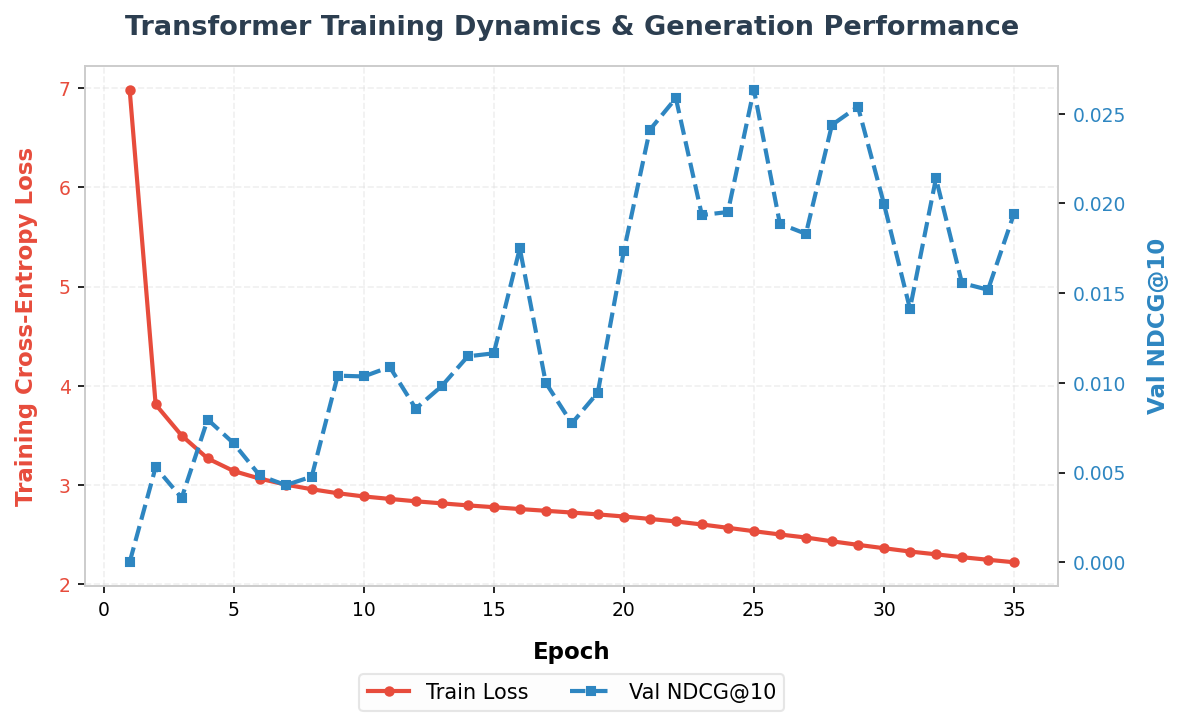

In [ ]:
import matplotlib.pyplot as plt
import os

epochs_seq = range(1, len(history_train_loss) + 1)


plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

fig, ax1 = plt.subplots(figsize=(8, 5), dpi=150)

color_loss = '#E74C3C'
ax1.set_xlabel('Epoch', fontsize=11, fontweight='semibold', labelpad=10)
ax1.set_ylabel('Training Cross-Entropy Loss', color=color_loss, fontsize=11, fontweight='semibold', labelpad=10)

line1 = ax1.plot(epochs_seq, history_train_loss, color=color_loss, linewidth=2, linestyle='-',
                 marker='o', markersize=4, label='Train Loss')

ax1.tick_params(axis='y', labelcolor=color_loss, labelsize=9)
ax1.tick_params(axis='x', labelsize=9)
ax1.grid(True, linestyle='--', alpha=0.5, color='#E0E0E0')

ax2 = ax1.twinx()
color_ndcg = '#2E86C1'
ax2.set_ylabel('Val NDCG@10', color=color_ndcg, fontsize=11, fontweight='semibold', labelpad=10)

line2 = ax2.plot(epochs_seq, history_val_ndcg, color=color_ndcg, linewidth=2, linestyle='--',
                 marker='s', markersize=4, label='Val NDCG@10')

ax2.tick_params(axis='y', labelcolor=color_ndcg, labelsize=9)
ax2.grid(False)

plt.title('Transformer Training Dynamics & Generation Performance',
          fontsize=13, fontweight='bold', pad=15, color='#2C3E50')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=2, frameon=True, facecolor='#FDFDFD', edgecolor='#E0E0E0', fontsize=10)

plt.tight_layout()


plot_path = os.path.join(CKPT_DIR, 'transformer_loss_ndcg.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Graph successfully saved to: {plot_path}")

plt.show()

## final evaluation on all users

In [ ]:

transformer_model.load_state_dict(torch.load(ckpt_path_best)['model_state_dict'])

total_users_to_evaluate = len(sequences_df)
print(f"\nStarting final evaluation on all {total_users_to_evaluate:,} users")


hits_5 = hits_10 = ndcg_5 = ndcg_10 = invalid_generations = total_evals = 0
start_time = time.time()

for idx, row in sequences_df.iterrows():
    history = row['train_sequence'] + [row['val_item']]
    target_item = row['test_item']

    src_tokens = []
    for item in history[-20:]:
        if item in semantic_id_map:
            src_tokens.extend(semantic_id_map[item])

    if len(src_tokens) == 0 or target_item not in semantic_id_map:
        continue

    src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)

    generated_tuples = beam_search_decode_unconstrained(transformer_model, src_tensor, beam_size=20, num_levels=4)
    candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

    recommended_items = []
    for tup in candidate_tuples:
        tup_key = tuple(tup)
        if tup_key in reverse_semantic_map:
            recommended_items.extend(reverse_semantic_map[tup_key])
        else:
            invalid_generations += 1

    unique_recs = list(dict.fromkeys(recommended_items))
    top_10 = unique_recs[:10]
    total_evals += 1

    if target_item in top_10[:5]:
        hits_5 += 1
        ndcg_5 += 1.0 / math.log2(top_10[:5].index(target_item) + 2)
    if target_item in top_10:
        hits_10 += 1
        ndcg_10 += 1.0 / math.log2(top_10.index(target_item) + 2)

    if total_evals % 1000 == 0:
        elapsed = time.time() - start_time
        print(f"Evaluated {total_evals:>5}/{total_users_to_evaluate} users... | Time elapsed: {elapsed/60:.1f} mins | Current NDCG@10: {ndcg_10/total_evals:.4f}")

n = max(total_evals, 1)
print("\n" + "="*30)
print("FINAL OFFICIAL METRICS")
print("="*30)
print(f"Recall@5:  {hits_5 / n:.4f}")
print(f"Recall@10: {hits_10 / n:.4f}")
print(f"NDCG@5:    {ndcg_5 / n:.4f}")
print(f"NDCG@10:   {ndcg_10 / n:.4f}")
print(f"Total invalid tuples generated: {invalid_generations}")
print("="*30)


Starting final evaluation on all 19,412 users
Evaluated  1000/19412 users... | Time elapsed: 0.6 mins | Current NDCG@10: 0.0191
Evaluated  2000/19412 users... | Time elapsed: 1.3 mins | Current NDCG@10: 0.0180
Evaluated  3000/19412 users... | Time elapsed: 1.9 mins | Current NDCG@10: 0.0170
Evaluated  4000/19412 users... | Time elapsed: 2.6 mins | Current NDCG@10: 0.0169
Evaluated  5000/19412 users... | Time elapsed: 3.2 mins | Current NDCG@10: 0.0168
Evaluated  6000/19412 users... | Time elapsed: 3.9 mins | Current NDCG@10: 0.0168
Evaluated  7000/19412 users... | Time elapsed: 4.5 mins | Current NDCG@10: 0.0173
Evaluated  8000/19412 users... | Time elapsed: 5.2 mins | Current NDCG@10: 0.0180
Evaluated  9000/19412 users... | Time elapsed: 5.8 mins | Current NDCG@10: 0.0180
Evaluated 10000/19412 users... | Time elapsed: 6.5 mins | Current NDCG@10: 0.0175
Evaluated 11000/19412 users... | Time elapsed: 7.1 mins | Current NDCG@10: 0.0183
Evaluated 12000/19412 users... | Time elapsed: 7.8 

## Qualitative analysis

In [ ]:
from collections import defaultdict
import math

# Create a dictionary mapping the item ID (asin) to its Title
# We use 'meta' which was created in Phase 1
item_id_to_title = dict(zip(meta['asin'], meta['title']))

prefix_groups = defaultdict(list)

# Group items by their first 2 semantic tokens (the Prefix)
# We use 'semantic_id_map' created in Phase 2
for item_id, semantic_id in semantic_id_map.items():
    if item_id in item_id_to_title:
        title = item_id_to_title[item_id]

        # Check if title is a string (ignores NaN/float values)
        if isinstance(title, str):
            prefix = tuple(semantic_id[:2]) # Grab the first two tokens
            prefix_groups[prefix].append(title)

# Print out groups that share the exact same prefix
print("QUALITATIVE ANALYSIS: SEMANTIC CLUSTERS")
count = 0
for prefix, titles in prefix_groups.items():
    if len(titles) >= 2: # Only show prefixes that group 2 or more items together
        print(f"Token Prefix {prefix}:")
        for title in titles[:4]: # Print up to 4 items in this group
            print(f"  - {title}")
        print("-" * 60)

        count += 1
        if count >= 3: # Stop after finding 3 good examples
            break

QUALITATIVE ANALYSIS: SEMANTIC CLUSTERS
Token Prefix (1, 264):
  - Little Red Tool Box: Magnetic Tabletop Learning Easel
  - The Book of Impossible Objects: 25 Eye-Popping Projects to Make, See &amp; Do
  - Original Sticker Book Starter Kit with 3 Puffy Sticker Packs By Sticker Farm
  - Mudpuppy Robots Magnetic Figures
------------------------------------------------------------
Token Prefix (65, 401):
  - Llama Llama Plush
  - FurReal Friends Hop `N Cuddle Tan Bunny
------------------------------------------------------------
Token Prefix (195, 398):
  - Acquire
  - Catan Card Game
  - Caylus
  - Battle of the Sexes 2nd Edition Board Game
------------------------------------------------------------


---

# Ablation Study

We systematically evaluate how each design choice affects recommendation quality.
Three independent ablation axes are covered:

1. **RQ-VAE codebook size K** (with L fixed at 3)
2. **RQ-VAE number of quantisation levels L** (with K fixed at 256)
3. **Transformer architecture** (hidden size d_model, number of encoder/decoder layers, attention heads)
4. **Beam size at inference**

Each ablation:
- trains (or reuses) the relevant component
- evaluates on the all users
- saves a dedicated **plot** (`.png`) and a **CSV** of all results


## Ablation study - shared helpers

In [ ]:
import os, math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ABLATION_DIR = os.path.join(CKPT_DIR, 'ablation')
os.makedirs(ABLATION_DIR, exist_ok=True)

def evaluate_model_unconstrained(model, sequences_df, semantic_map, reverse_map, beam_size=20, num_levels=4):
    model.eval()
    hits5 = hits10 = ndcg5 = ndcg10 = invalid_generations = total_evals = 0
    test_sample = sequences_df # Testing on the entire dataset!
    total_users = len(test_sample)

    print(f"\nStarting rigorous evaluation on all {total_users} users...")
    start_eval_time = time.time()

    for _, row in test_sample.iterrows():
        history = row['train_sequence'] + [row['val_item']]
        target_item = row['test_item']

        src_tokens = []
        for item in history[-20:]:
            if item in semantic_map:
                src_tokens.extend(semantic_map[item])

        if len(src_tokens) == 0 or target_item not in semantic_map:
            continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)

        # Uses existing unconstrained decoding function
        generated_tuples = beam_search_decode_unconstrained(model, src_tensor, beam_size=beam_size, num_levels=num_levels)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            key = tuple(tup)
            if key in reverse_map:
                recommended_items.extend(reverse_map[key])
            else:
                invalid_generations += 1

        unique_recs = list(dict.fromkeys(recommended_items))
        top_10 = unique_recs[:10]
        total_evals += 1

        if target_item in top_10[:5]:
            hits5 += 1
            ndcg5 += 1.0 / math.log2(top_10[:5].index(target_item) + 2)
        if target_item in top_10:
            hits10 += 1
            ndcg10 += 1.0 / math.log2(top_10.index(target_item) + 2)

        if total_evals % 2000 == 0:
            print(f"  Evaluated {total_evals:>5}/{total_users} | Time elapsed: {(time.time() - start_eval_time)/60:.1f}m")

    n = max(total_evals, 1)
    return {
        'Recall@5':  hits5 / n,
        'Recall@10': hits10 / n,
        'NDCG@5':    ndcg5 / n,
        'NDCG@10':   ndcg10 / n,
        'invalid_rate': invalid_generations / max(total_evals * beam_size, 1),
    }

#  Transformer Trainer
def train_transformer_config(
        d_model, nhead, num_enc_layers, num_dec_layers,
        dim_feedforward, dropout, train_loader, sequences_df,
        semantic_map, reverse_map, vocab_size, num_levels=4,
        num_epochs=30, patience=10, # <-- UPDATED PARAMETERS
        beam_size=20, n_eval_users=300,
        ckpt_tag='ablation', pad_idx=1024):

    model = GenerativeRecommender(
        vocab_size=vocab_size, d_model=d_model, nhead=nhead,
        num_encoder_layers=num_enc_layers, num_decoder_layers=num_dec_layers,
        dim_feedforward=dim_feedforward, dropout=dropout,
        pad_idx=pad_idx
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    scheduler = get_inv_sqrt_schedule_with_warmup(optimizer, num_warmup_steps=int(len(train_loader)*2))
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=0.1)

    ckpt_path = os.path.join(ABLATION_DIR, f'{ckpt_tag}_best.pt')
    best_val, no_improve = -1.0, 0

    print(f"\n Starting Training for {ckpt_tag}")
    for epoch in range(num_epochs):
        start_epoch = time.time()
        model.train()
        epoch_loss = 0.0
        for src, tgt_in, tgt_out in train_loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            optimizer.zero_grad()
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        val_ndcg = get_val_ndcg(model, sequences_df, num_users=n_eval_users)
        print(f'  Ep {epoch+1:>2}/{num_epochs} | Time: {time.time()-start_epoch:.1f}s | loss={avg_loss:.4f} | val_ndcg10={val_ndcg:.4f}')

        if val_ndcg > best_val:
            best_val = val_ndcg
            no_improve = 0
            torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f' Early stopping at epoch {epoch+1}')
                break

    print(f"\nLoading best model for {ckpt_tag} and running final test...")
    model.load_state_dict(torch.load(ckpt_path)['model_state_dict'])
    metrics = evaluate_model_unconstrained(
        model, sequences_df, semantic_map, reverse_map,
        beam_size=beam_size, num_levels=num_levels
    )
    return metrics

# Plotting Helper
def bar_plot_metric(results_df, x_col, metric_cols, title, fname, x_label=None):
    x = np.arange(len(results_df))
    width = 0.2
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    fig, ax = plt.subplots(figsize=(max(7, len(results_df) * 1.6), 5))
    for i, (col, color) in enumerate(zip(metric_cols, colors)):
        offset = (i - len(metric_cols) / 2 + 0.5) * width
        bars = ax.bar(x + offset, results_df[col], width, label=col, color=color, alpha=0.85)
        ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=8)

    ax.set_xlabel(x_label or x_col, fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df[x_col].astype(str), fontsize=10)
    ax.legend(fontsize=9)
    ax.set_ylim(0, results_df[metric_cols].max().max() * 1.25 + 0.002)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    fig.tight_layout()
    path = os.path.join(ABLATION_DIR, fname)
    fig.savefig(path, dpi=150)
    plt.show()
    print(f'Plot saved → {path}')

print('Ablation helpers loaded successfully!')

✅ Rigorous Ablation helpers loaded successfully!


---
## Ablation 1 - RQ-VAE Codebook Size K

We fix the number of quantisation levels at **L = 3** and vary the per-level
codebook size K ∈ {64, 128, 256}.  


In [ ]:
# ablation prerequists
import math
import torch

#  Reverse Semantic Map
reverse_semantic_map = {}
for item_id, sem_id in semantic_id_map.items():
    tup = tuple(sem_id)
    if tup not in reverse_semantic_map:
        reverse_semantic_map[tup] = []
    reverse_semantic_map[tup].append(item_id)

print(f"Reverse semantic map created! Unique prefixes: {len(reverse_semantic_map)}")

# Beam Search Decoder
def beam_search_decode_unconstrained(model, src, beam_size=20, num_levels=4):
    model.eval()
    batch_size = src.size(0)
    current_seqs = torch.full((batch_size, 1), BOS_IDX, dtype=torch.long, device=device)
    beam_scores = torch.zeros(batch_size, 1, device=device)

    with torch.no_grad():
        for step in range(num_levels):
            num_beams = current_seqs.size(0) // batch_size
            src_repeated = src.repeat_interleave(num_beams, dim=0)
            logits = model(src_repeated, current_seqs)
            next_token_logits = logits[:, -1, :]

            next_token_logprobs = torch.log_softmax(next_token_logits, dim=-1)
            next_token_logprobs = next_token_logprobs.view(batch_size, num_beams, VOCAB_SIZE)
            scores = beam_scores.view(batch_size, num_beams, 1) + next_token_logprobs
            scores = scores.view(batch_size, -1)

            topk_scores, topk_indices = torch.topk(scores, min(beam_size, scores.size(1)), dim=1)
            beam_indices = torch.div(topk_indices, VOCAB_SIZE, rounding_mode='floor')
            token_indices = topk_indices % VOCAB_SIZE

            new_seqs = []
            for b in range(batch_size):
                batch_seqs = []
                for i in range(topk_indices.size(1)):
                    parent_beam_idx = beam_indices[b, i]
                    new_token = token_indices[b, i].unsqueeze(0)
                    parent_seq = current_seqs[b * num_beams + parent_beam_idx]
                    batch_seqs.append(torch.cat([parent_seq, new_token]))
                new_seqs.append(torch.stack(batch_seqs))

            current_seqs = torch.stack(new_seqs)
            current_seqs = current_seqs.view(batch_size * topk_indices.size(1), -1)
            beam_scores = topk_scores.view(-1)

    final_seqs = current_seqs.view(batch_size, -1, num_levels + 1)
    return final_seqs[:, :, 1:]

# Learning Rate Scheduler
def get_inv_sqrt_schedule_with_warmup(optimizer, num_warmup_steps=10000):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        return (num_warmup_steps ** 0.5) * (current_step ** -0.5)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

#  Validation Helper
def get_val_ndcg(model, test_df, num_users=300):
    ndcg_10 = 0
    test_sample = test_df.sample(n=num_users, random_state=42)

    for _, row in test_sample.iterrows():
        history = row['train_sequence']
        target_item = row['val_item']

        src_tokens = []
        for item in history[-20:]:
            if item in semantic_id_map:
                src_tokens.extend(semantic_id_map[item])

        if len(src_tokens) == 0 or target_item not in semantic_id_map:
            continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = beam_search_decode_unconstrained(model, src_tensor, beam_size=20, num_levels=4)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            tup_key = tuple(tup)
            if tup_key in reverse_semantic_map:
                recommended_items.extend(reverse_semantic_map[tup_key])

        unique_recs = list(dict.fromkeys(recommended_items))
        top_10 = unique_recs[:10]

        if target_item in top_10:
            rank = top_10.index(target_item) + 1
            ndcg_10 += 1.0 / math.log2(rank + 1)

    return ndcg_10 / len(test_sample)

print("All missing Phase 5 dependencies loaded successfully!")

✅ Reverse semantic map created! Unique prefixes: 11924
✅ All missing Phase 5 dependencies loaded successfully!


In [ ]:
# ================================================================
# ABLATION 1 — RQ-VAE CODEBOOK SIZE K (ALL USERS EVALUATION)
# ================================================================
import os, json, math, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(">>> STARTING ABLATION 1: RQ-VAE CODEBOOK SIZE K <<<")

# ensure embeddings are loaded
cached_data = np.load(EMB_FILE, allow_pickle=True)
item_ids = cached_data['item_ids']
embeddings = cached_data['embeddings']

#pre-calculate item popularity for suffixing
item_popularity = {}
for _, row in sequences_df.iterrows():
    for item in row['train_sequence']:
        item_popularity[item] = item_popularity.get(item, 0) + 1

def safe_beam_search(model, src, beam_size, num_levels, bos_idx, vocab_size):
    model.eval()
    batch_size = src.size(0)
    current_seqs = torch.full((batch_size, 1), bos_idx, dtype=torch.long, device=device)
    beam_scores = torch.zeros(batch_size, 1, device=device)

    with torch.no_grad():
        for step in range(num_levels):
            num_beams = current_seqs.size(0) // batch_size
            src_repeated = src.repeat_interleave(num_beams, dim=0)
            logits = model(src_repeated, current_seqs)
            next_token_logits = logits[:, -1, :]

            next_token_logprobs = torch.log_softmax(next_token_logits, dim=-1)
            next_token_logprobs = next_token_logprobs.view(batch_size, num_beams, vocab_size)
            scores = beam_scores.view(batch_size, num_beams, 1) + next_token_logprobs
            scores = scores.view(batch_size, -1)

            topk_scores, topk_indices = torch.topk(scores, min(beam_size, scores.size(1)), dim=1)
            beam_indices = torch.div(topk_indices, vocab_size, rounding_mode='floor')
            token_indices = topk_indices % vocab_size

            new_seqs = []
            for b in range(batch_size):
                batch_seqs = []
                for i in range(topk_indices.size(1)):
                    parent_beam_idx = beam_indices[b, i]
                    new_token = token_indices[b, i].unsqueeze(0)
                    parent_seq = current_seqs[b * num_beams + parent_beam_idx]
                    batch_seqs.append(torch.cat([parent_seq, new_token]))
                new_seqs.append(torch.stack(batch_seqs))

            current_seqs = torch.stack(new_seqs)
            current_seqs = current_seqs.view(batch_size * topk_indices.size(1), -1)
            beam_scores = topk_scores.view(-1)

    final_seqs = current_seqs.view(batch_size, -1, num_levels + 1)
    return final_seqs[:, :, 1:]

def safe_val_ndcg(model, test_df, sem_map, rev_map, bos_idx, vocab_size, num_levels, num_users=300):
    ndcg_10 = 0
    test_sample = test_df.sample(n=num_users, random_state=42)

    for _, row in test_sample.iterrows():
        history = row['train_sequence']
        target_item = row['val_item']

        src_tokens = []
        for item in history[-20:]:
            if item in sem_map:
                src_tokens.extend(sem_map[item])

        if len(src_tokens) == 0 or target_item not in sem_map:
            continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = safe_beam_search(model, src_tensor, 20, num_levels, bos_idx, vocab_size)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            tup_key = tuple(tup)
            if tup_key in rev_map:
                recommended_items.extend(rev_map[tup_key])

        unique_recs = list(dict.fromkeys(recommended_items))
        top_10 = unique_recs[:10]

        if target_item in top_10:
            rank = top_10.index(target_item) + 1
            ndcg_10 += 1.0 / math.log2(rank + 1)

    return ndcg_10 / len(test_sample)

# ABLATION LOOP
K_VALUES = [64, 128, 256]
L_FIXED = 3
abl1_rows = []

for K in K_VALUES:
    torch.cuda.empty_cache()
    tag = f'K{K}_L{L_FIXED}'
    print(f'\n{"="*60}')
    print(f'  Ablation 1 — Codebook Size K={K}')
    print(f'{"="*60}')

    # Train
    rqvae_ckpt = os.path.join(ABLATION_DIR, f'rqvae_{tag}.pt')
    rqvae_abl = RQVAE(input_dim=embeddings.shape[1], latent_dim=32, num_levels=L_FIXED, codebook_size=K).to(device)

    if os.path.exists(rqvae_ckpt):
        print(f'  Loading cached RQ-VAE from {rqvae_ckpt}')
        rqvae_abl.load_state_dict(torch.load(rqvae_ckpt, map_location=device))
    else:
        print(f'  Training RQ-VAE for 20,000 epochs...')
        emb_tensor = torch.tensor(embeddings, dtype=torch.float32)
        rqvae_loader = DataLoader(TensorDataset(emb_tensor), batch_size=1024, shuffle=True)
        rqvae_opt = optim.Adagrad(rqvae_abl.parameters(), lr=0.4)

        rqvae_abl.train()
        for ep in range(20000):
            ep_loss = 0.0
            for (batch_emb,) in rqvae_loader:
                batch_emb = batch_emb.to(device)
                rqvae_opt.zero_grad()
                recon, indices, commit_loss, cb_loss = rqvae_abl(batch_emb)
                loss = nn.functional.mse_loss(recon, batch_emb) + 0.25 * commit_loss + cb_loss
                loss.backward()
                rqvae_opt.step()
                ep_loss += loss.item()

            if (ep + 1) % 500 == 0:
                print(f'    RQ-VAE ep {ep+1:>5}/20000  loss={ep_loss/len(rqvae_loader):.4f}')

        torch.save(rqvae_abl.state_dict(), rqvae_ckpt)

    #  Extract Semantic IDs
    rqvae_abl.eval()
    base_semantic_id_map = {}
    with torch.no_grad():
        emb_t = torch.tensor(embeddings, dtype=torch.float32, device=device)
        _, all_indices, _, _ = rqvae_abl(emb_t)
        all_indices = all_indices.cpu().numpy()

        for i, item_id in enumerate(item_ids):
            sid = [int(all_indices[i, l]) + l * K for l in range(L_FIXED)]
            base_semantic_id_map[item_id] = sid

    COLLISION_OFFSET = L_FIXED * K
    collision_counter = {}
    for item_id in item_ids:
        tup = tuple(base_semantic_id_map[item_id])
        collision_counter[tup] = collision_counter.get(tup, 0) + 1

    sem_map_abl = {}
    for item_id in item_ids:
        tup = tuple(base_semantic_id_map[item_id])
        if collision_counter[tup] > 1:
            colliding_items = [i for i in item_ids if tuple(base_semantic_id_map[i]) == tup]
            colliding_items.sort(key=lambda x: item_popularity.get(x, 0), reverse=True)
            rank = colliding_items.index(item_id)
            sem_map_abl[item_id] = list(tup) + [COLLISION_OFFSET + rank]
        else:
            sem_map_abl[item_id] = list(tup) + [COLLISION_OFFSET]

    # dynamic Variables
    rev_map_abl = {}
    max_token = 0
    for item_id, sid in sem_map_abl.items():
        tup = tuple(sid)
        rev_map_abl.setdefault(tup, []).append(item_id)
        max_token = max(max_token, max(sid))

    vocab_size = max_token + 4
    pad_idx = vocab_size - 4
    bos_idx = vocab_size - 3
    eos_idx = vocab_size - 2
    num_levels = L_FIXED + 1

    # local Dataset
    class AblSeqDataset(torch.utils.data.Dataset):
        def __init__(self, seq_df, sem_map, bos, eos, max_items=20):
            self.data = []
            for _, row in seq_df.iterrows():
                train_seq = row['train_sequence']
                for i in range(1, len(train_seq)):
                    history = train_seq[:i][-max_items:]
                    target = train_seq[i]

                    src_tokens = []
                    for item in history:
                        if item in sem_map:
                            src_tokens.extend(sem_map[item])

                    tgt_tokens = []
                    if target in sem_map:
                        tgt_tokens.extend(sem_map[target])

                    if len(src_tokens) > 0 and len(tgt_tokens) > 0:
                        self.data.append({
                            'src':     torch.tensor(src_tokens, dtype=torch.long),
                            'tgt_in':  torch.tensor([bos] + tgt_tokens, dtype=torch.long),
                            'tgt_out': torch.tensor(tgt_tokens + [eos], dtype=torch.long),
                        })
        def __len__(self): return len(self.data)
        def __getitem__(self, idx): return self.data[idx]

    def abl_collate(batch):
        src     = pad_sequence([b['src']     for b in batch], padding_value=pad_idx, batch_first=True)
        tgt_in  = pad_sequence([b['tgt_in']  for b in batch], padding_value=pad_idx, batch_first=True)
        tgt_out = pad_sequence([b['tgt_out'] for b in batch], padding_value=pad_idx, batch_first=True)
        return src, tgt_in, tgt_out

    abl_dataset = AblSeqDataset(sequences_df, sem_map_abl, bos=bos_idx, eos=eos_idx)
    abl_loader = DataLoader(abl_dataset, batch_size=256, shuffle=True, collate_fn=abl_collate)

    # local Transformer Training
    print(f'  Training Transformer for K={K} ...')
    transformer_model = GenerativeRecommender(
        vocab_size=vocab_size, d_model=384, nhead=6,
        num_encoder_layers=4, num_decoder_layers=4,
        dim_feedforward=1024, dropout=0.2, pad_idx=pad_idx
    ).to(device)

    optimizer = optim.AdamW(transformer_model.parameters(), lr=1e-3, weight_decay=0.01)

    def lr_lambda(current_step):
        warmup = max(1, len(abl_loader)*2)
        if current_step < warmup:
            return float(current_step) / float(warmup)
        return (warmup ** 0.5) * (current_step ** -0.5)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=0.1)

    best_val, no_improve = -1.0, 0
    ckpt_path = os.path.join(ABLATION_DIR, f'transformer_{tag}_best.pt')

    for epoch in range(30):
        transformer_model.train()
        epoch_loss = 0.0
        for src, tgt_in, tgt_out in abl_loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            optimizer.zero_grad()
            logits = transformer_model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(abl_loader)


        val_ndcg = safe_val_ndcg(transformer_model, sequences_df, sem_map_abl, rev_map_abl, bos_idx, vocab_size, num_levels)
        print(f'    Ep {epoch+1:>2}/30 | loss={avg_loss:.4f} | val_ndcg10={val_ndcg:.4f}')

        if val_ndcg > best_val:
            best_val = val_ndcg
            no_improve = 0
            torch.save({'model_state_dict': transformer_model.state_dict()}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= 10:
                print(f'    🚨 Early stopping at epoch {epoch+1}')
                break

    # Final Test on ALL Users
    transformer_model.load_state_dict(torch.load(ckpt_path)['model_state_dict'])
    transformer_model.eval()
    hits5 = hits10 = ndcg5 = ndcg10 = invalid_gens = total_evals = 0

    test_sample = sequences_df
    total_users_to_eval = len(test_sample)

    print(f'    Starting rigorous final evaluation on ALL {total_users_to_eval} users...')
    eval_start_time = time.time()

    for _, row in test_sample.iterrows():
        history = row['train_sequence'] + [row['val_item']]
        target_item = row['test_item']
        src_tokens = []
        for item in history[-20:]:
            if item in sem_map_abl: src_tokens.extend(sem_map_abl[item])

        if len(src_tokens) == 0 or target_item not in sem_map_abl: continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = safe_beam_search(transformer_model, src_tensor, 20, num_levels, bos_idx, vocab_size)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            if tuple(tup) in rev_map_abl: recommended_items.extend(rev_map_abl[tuple(tup)])
            else: invalid_gens += 1

        top_10 = list(dict.fromkeys(recommended_items))[:10]
        total_evals += 1

        if target_item in top_10[:5]:
            hits5 += 1
            ndcg5 += 1.0 / math.log2(top_10[:5].index(target_item) + 2)
        if target_item in top_10:
            hits10 += 1
            ndcg10 += 1.0 / math.log2(top_10.index(target_item) + 2)

        if total_evals % 2000 == 0:
            elapsed_mins = (time.time() - eval_start_time) / 60
            print(f'      Evaluated {total_evals:>5}/{total_users_to_eval} | Time: {elapsed_mins:.1f}m | Curr NDCG@10: {ndcg10/total_evals:.4f}')

    n = max(total_evals, 1)
    metrics = {
        'Recall@5': hits5/n, 'Recall@10': hits10/n,
        'NDCG@5': ndcg5/n, 'NDCG@10': ndcg10/n,
        'invalid_rate': invalid_gens / max(total_evals * 20, 1)
    }

    row = {'K': K, **metrics}
    abl1_rows.append(row)
    print(f'  Result for K={K} → {metrics}')


abl1_df = pd.DataFrame(abl1_rows)
csv_path = os.path.join(ABLATION_DIR, 'ablation_codebook_K.csv')
abl1_df.to_csv(csv_path, index=False)
print(f'\nCSV saved → {csv_path}')
print(abl1_df.to_string(index=False))

bar_plot_metric(
    abl1_df, x_col='K',
    metric_cols=['Recall@5', 'Recall@10', 'NDCG@5', 'NDCG@10'],
    title='Ablation 1 — Effect of RQ-VAE Codebook Size K (L=3)',
    fname='ablation_codebook_K.png', x_label='Codebook Size K'
)

---
## Ablation 2 - RQ-VAE Number of Quantisation Levels L

We fix **K = 256** and vary L ∈ {2, 3, 4}.  


In [ ]:

# ABLATION 2 — RQ-VAE NUMBER OF LEVELS L

import os, json, math, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(">>> STARTING ABLATION 2: RQ-VAE QUANTISATION LEVELS L <<<")

# Ensure embeddings are loaded
cached_data = np.load(EMB_FILE, allow_pickle=True)
item_ids = cached_data['item_ids']
embeddings = cached_data['embeddings']

# Pre-calculate item popularity for suffixing
item_popularity = {}
for _, row in sequences_df.iterrows():
    for item in row['train_sequence']:
        item_popularity[item] = item_popularity.get(item, 0) + 1

def safe_beam_search(model, src, beam_size, num_levels, bos_idx, vocab_size):
    model.eval()
    batch_size = src.size(0)
    current_seqs = torch.full((batch_size, 1), bos_idx, dtype=torch.long, device=device)
    beam_scores = torch.zeros(batch_size, 1, device=device)

    with torch.no_grad():
        for step in range(num_levels):
            num_beams = current_seqs.size(0) // batch_size
            src_repeated = src.repeat_interleave(num_beams, dim=0)
            logits = model(src_repeated, current_seqs)
            next_token_logits = logits[:, -1, :]

            next_token_logprobs = torch.log_softmax(next_token_logits, dim=-1)
            next_token_logprobs = next_token_logprobs.view(batch_size, num_beams, vocab_size)
            scores = beam_scores.view(batch_size, num_beams, 1) + next_token_logprobs
            scores = scores.view(batch_size, -1)

            topk_scores, topk_indices = torch.topk(scores, min(beam_size, scores.size(1)), dim=1)
            beam_indices = torch.div(topk_indices, vocab_size, rounding_mode='floor')
            token_indices = topk_indices % vocab_size

            new_seqs = []
            for b in range(batch_size):
                batch_seqs = []
                for i in range(topk_indices.size(1)):
                    parent_beam_idx = beam_indices[b, i]
                    new_token = token_indices[b, i].unsqueeze(0)
                    parent_seq = current_seqs[b * num_beams + parent_beam_idx]
                    batch_seqs.append(torch.cat([parent_seq, new_token]))
                new_seqs.append(torch.stack(batch_seqs))

            current_seqs = torch.stack(new_seqs)
            current_seqs = current_seqs.view(batch_size * topk_indices.size(1), -1)
            beam_scores = topk_scores.view(-1)

    final_seqs = current_seqs.view(batch_size, -1, num_levels + 1)
    return final_seqs[:, :, 1:]

def safe_val_ndcg(model, test_df, sem_map, rev_map, bos_idx, vocab_size, num_levels, num_users=300):
    ndcg_10 = 0
    test_sample = test_df.sample(n=num_users, random_state=42)

    for _, row in test_sample.iterrows():
        history = row['train_sequence']
        target_item = row['val_item']

        src_tokens = []
        for item in history[-20:]:
            if item in sem_map:
                src_tokens.extend(sem_map[item])

        if len(src_tokens) == 0 or target_item not in sem_map:
            continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = safe_beam_search(model, src_tensor, 20, num_levels, bos_idx, vocab_size)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            tup_key = tuple(tup)
            if tup_key in rev_map:
                recommended_items.extend(rev_map[tup_key])

        unique_recs = list(dict.fromkeys(recommended_items))
        top_10 = unique_recs[:10]

        if target_item in top_10:
            rank = top_10.index(target_item) + 1
            ndcg_10 += 1.0 / math.log2(rank + 1)

    return ndcg_10 / len(test_sample)

L_VALUES = [2, 3, 4]
K_FIXED = 256
abl2_rows = []

for L in L_VALUES:
    torch.cuda.empty_cache()
    tag = f'K{K_FIXED}_L{L}'
    print(f'\n{"="*60}')
    print(f'  Ablation 2 — Quantisation Levels L={L} (K=256)')
    print(f'{"="*60}')

    if L == 3:
        rqvae_ckpt = os.path.join(CKPT_DIR, 'rq_vae_model.pt')
        print(f'  Using BASELINE RQ-VAE from {rqvae_ckpt}')
    else:
        # Pull ablation variants from the ablation directory
        rqvae_ckpt = os.path.join(ABLATION_DIR, f'rqvae_{tag}.pt')

    rqvae_abl = RQVAE(input_dim=embeddings.shape[1], latent_dim=32, num_levels=L, codebook_size=K_FIXED).to(device)

    if os.path.exists(rqvae_ckpt):
        print(f'  Loading cached RQ-VAE from {rqvae_ckpt}')
        rqvae_abl.load_state_dict(torch.load(rqvae_ckpt, map_location=device))
    else:
        print(f'  Training RQ-VAE for 20,000 epochs')
        emb_tensor = torch.tensor(embeddings, dtype=torch.float32)
        rqvae_loader = DataLoader(TensorDataset(emb_tensor), batch_size=1024, shuffle=True)
        rqvae_opt = optim.Adagrad(rqvae_abl.parameters(), lr=0.4)

        rqvae_abl.train()
        for ep in range(20000):
            ep_loss = 0.0
            for (batch_emb,) in rqvae_loader:
                batch_emb = batch_emb.to(device)
                rqvae_opt.zero_grad()
                recon, indices, commit_loss, cb_loss = rqvae_abl(batch_emb)
                loss = nn.functional.mse_loss(recon, batch_emb) + 0.25 * commit_loss + cb_loss
                loss.backward()
                rqvae_opt.step()
                ep_loss += loss.item()

            if (ep + 1) % 5000 == 0:
                print(f'    RQ-VAE ep {ep+1:>5}/20000  loss={ep_loss/len(rqvae_loader):.4f}')

        torch.save(rqvae_abl.state_dict(), rqvae_ckpt)

    rqvae_abl.eval()
    base_semantic_id_map = {}
    with torch.no_grad():
        emb_t = torch.tensor(embeddings, dtype=torch.float32, device=device)
        _, all_indices, _, _ = rqvae_abl(emb_t)
        all_indices = all_indices.cpu().numpy()

        for i, item_id in enumerate(item_ids):
            sid = [int(all_indices[i, l]) + l * K_FIXED for l in range(L)]
            base_semantic_id_map[item_id] = sid

    COLLISION_OFFSET = L * K_FIXED
    collision_counter = {}
    for item_id in item_ids:
        tup = tuple(base_semantic_id_map[item_id])
        collision_counter[tup] = collision_counter.get(tup, 0) + 1

    sem_map_abl = {}
    for item_id in item_ids:
        tup = tuple(base_semantic_id_map[item_id])
        if collision_counter[tup] > 1:
            colliding_items = [i for i in item_ids if tuple(base_semantic_id_map[i]) == tup]
            colliding_items.sort(key=lambda x: item_popularity.get(x, 0), reverse=True)
            rank = colliding_items.index(item_id)
            sem_map_abl[item_id] = list(tup) + [COLLISION_OFFSET + rank]
        else:
            sem_map_abl[item_id] = list(tup) + [COLLISION_OFFSET]

    rev_map_abl = {}
    max_token = 0
    for item_id, sid in sem_map_abl.items():
        tup = tuple(sid)
        rev_map_abl.setdefault(tup, []).append(item_id)
        max_token = max(max_token, max(sid))

    vocab_size = max_token + 4
    pad_idx = vocab_size - 4
    bos_idx = vocab_size - 3
    eos_idx = vocab_size - 2
    num_levels = L + 1

    class AblSeqDataset(torch.utils.data.Dataset):
        def __init__(self, seq_df, sem_map, bos, eos, max_items=20):
            self.data = []
            for _, row in seq_df.iterrows():
                train_seq = row['train_sequence']
                for i in range(1, len(train_seq)):
                    history = train_seq[:i][-max_items:]
                    target = train_seq[i]

                    src_tokens = []
                    for item in history:
                        if item in sem_map:
                            src_tokens.extend(sem_map[item])

                    tgt_tokens = []
                    if target in sem_map:
                        tgt_tokens.extend(sem_map[target])

                    if len(src_tokens) > 0 and len(tgt_tokens) > 0:
                        self.data.append({
                            'src':     torch.tensor(src_tokens, dtype=torch.long),
                            'tgt_in':  torch.tensor([bos] + tgt_tokens, dtype=torch.long),
                            'tgt_out': torch.tensor(tgt_tokens + [eos], dtype=torch.long),
                        })
        def __len__(self): return len(self.data)
        def __getitem__(self, idx): return self.data[idx]

    def abl_collate(batch):
        src     = pad_sequence([b['src']     for b in batch], padding_value=pad_idx, batch_first=True)
        tgt_in  = pad_sequence([b['tgt_in']  for b in batch], padding_value=pad_idx, batch_first=True)
        tgt_out = pad_sequence([b['tgt_out'] for b in batch], padding_value=pad_idx, batch_first=True)
        return src, tgt_in, tgt_out

    abl_dataset = AblSeqDataset(sequences_df, sem_map_abl, bos=bos_idx, eos=eos_idx)
    abl_loader = DataLoader(abl_dataset, batch_size=256, shuffle=True, collate_fn=abl_collate)


    print(f'  Training Transformer for L={L} ...')
    transformer_model = GenerativeRecommender(
        vocab_size=vocab_size, d_model=384, nhead=6,
        num_encoder_layers=4, num_decoder_layers=4,
        dim_feedforward=1024, dropout=0.2, pad_idx=pad_idx
    ).to(device)

    optimizer = optim.AdamW(transformer_model.parameters(), lr=1e-3, weight_decay=0.01)

    def lr_lambda(current_step):
        warmup = max(1, len(abl_loader)*2)
        if current_step < warmup:
            return float(current_step) / float(warmup)
        return (warmup ** 0.5) * (current_step ** -0.5)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=0.1)

    best_val, no_improve = -1.0, 0
    ckpt_path = os.path.join(ABLATION_DIR, f'transformer_{tag}_best.pt')

    for epoch in range(30):
        transformer_model.train()
        epoch_loss = 0.0
        for src, tgt_in, tgt_out in abl_loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            optimizer.zero_grad()
            logits = transformer_model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(abl_loader)

        val_ndcg = safe_val_ndcg(transformer_model, sequences_df, sem_map_abl, rev_map_abl, bos_idx, vocab_size, num_levels)
        print(f'    Ep {epoch+1:>2}/30 | loss={avg_loss:.4f} | val_ndcg10={val_ndcg:.4f}')

        if val_ndcg > best_val:
            best_val = val_ndcg
            no_improve = 0
            torch.save({'model_state_dict': transformer_model.state_dict()}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= 10:
                print(f'Early stopping at epoch {epoch+1}')
                break

    transformer_model.load_state_dict(torch.load(ckpt_path)['model_state_dict'])
    transformer_model.eval()
    hits5 = hits10 = ndcg5 = ndcg10 = invalid_gens = total_evals = 0
    test_sample = sequences_df
    total_users_to_eval = len(test_sample)

    print(f'    Starting rigorous final evaluation on ALL {total_users_to_eval} users...')
    eval_start_time = time.time()

    for _, row in test_sample.iterrows():
        history = row['train_sequence'] + [row['val_item']]
        target_item = row['test_item']
        src_tokens = []
        for item in history[-20:]:
            if item in sem_map_abl: src_tokens.extend(sem_map_abl[item])

        if len(src_tokens) == 0 or target_item not in sem_map_abl: continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = safe_beam_search(transformer_model, src_tensor, 20, num_levels, bos_idx, vocab_size)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            if tuple(tup) in rev_map_abl: recommended_items.extend(rev_map_abl[tuple(tup)])
            else: invalid_gens += 1

        top_10 = list(dict.fromkeys(recommended_items))[:10]
        total_evals += 1

        if target_item in top_10[:5]:
            hits5 += 1
            ndcg5 += 1.0 / math.log2(top_10[:5].index(target_item) + 2)
        if target_item in top_10:
            hits10 += 1
            ndcg10 += 1.0 / math.log2(top_10.index(target_item) + 2)

        if total_evals % 2000 == 0:
            elapsed_mins = (time.time() - eval_start_time) / 60
            print(f'      Evaluated {total_evals:>5}/{total_users_to_eval} | Time: {elapsed_mins:.1f}m | Curr NDCG@10: {ndcg10/total_evals:.4f}')

    n = max(total_evals, 1)
    metrics = {
        'Recall@5': hits5/n, 'Recall@10': hits10/n,
        'NDCG@5': ndcg5/n, 'NDCG@10': ndcg10/n,
        'invalid_rate': invalid_gens / max(total_evals * 20, 1)
    }

    row = {'L': L, **metrics}
    abl2_rows.append(row)
    print(f'  Result for L={L} → {metrics}')


abl2_df = pd.DataFrame(abl2_rows)
csv_path = os.path.join(ABLATION_DIR, 'ablation_rqvae_L.csv')
abl2_df.to_csv(csv_path, index=False)
print(f'\nCSV saved → {csv_path}')
print(abl2_df.to_string(index=False))

try:
    bar_plot_metric(
        abl2_df, x_col='L',
        metric_cols=['Recall@5', 'Recall@10', 'NDCG@5', 'NDCG@10'],
        title='Ablation 2 — Effect of RQ-VAE Levels L (K=256)',
        fname='ablation_rqvae_L.png', x_label='Number of RQ-VAE Levels L'
    )
except NameError:
    print("Plotting function 'bar_plot_metric' not found, but CSV saved successfully.")

In [ ]:

# SHARED SETUP FOR ABLATIONS 3, 4, and 5 (THE TRANSFORMER)

import os, json, math, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(">>> BUILDING SHARED ENVIRONMENT FOR TRANSFORMER ABLATIONS <<<")

# Load Embeddings & Popularity
cached_data = np.load(EMB_FILE, allow_pickle=True)
item_ids = cached_data['item_ids']
embeddings = cached_data['embeddings']

item_popularity = {}
for _, row in sequences_df.iterrows():
    for item in row['train_sequence']:
        item_popularity[item] = item_popularity.get(item, 0) + 1

#Load the Baseline RQ-VAE (K=256, L=3)
K_FIXED = 256
L_FIXED = 3
rqvae_ckpt = os.path.join(CKPT_DIR, 'rq_vae_model.pt')

if not os.path.exists(rqvae_ckpt):
    raise FileNotFoundError(f"Missing {rqvae_ckpt}! Make sure you ran Ablation 1 or 2.")

rqvae_base = RQVAE(input_dim=embeddings.shape[1], latent_dim=32, num_levels=L_FIXED, codebook_size=K_FIXED).to(device)
rqvae_base.load_state_dict(torch.load(rqvae_ckpt, map_location=device))
rqvae_base.eval()

# extract IDs Exactly Once
base_semantic_id_map = {}
with torch.no_grad():
    emb_t = torch.tensor(embeddings, dtype=torch.float32, device=device)
    _, all_indices, _, _ = rqvae_base(emb_t)
    all_indices = all_indices.cpu().numpy()
    for i, item_id in enumerate(item_ids):
        sid = [int(all_indices[i, l]) + l * K_FIXED for l in range(L_FIXED)]
        base_semantic_id_map[item_id] = sid

COLLISION_OFFSET = L_FIXED * K_FIXED
collision_counter = {}
for item_id in item_ids:
    tup = tuple(base_semantic_id_map[item_id])
    collision_counter[tup] = collision_counter.get(tup, 0) + 1

shared_sem_map = {}
for item_id in item_ids:
    tup = tuple(base_semantic_id_map[item_id])
    if collision_counter[tup] > 1:
        colliding_items = [i for i in item_ids if tuple(base_semantic_id_map[i]) == tup]
        colliding_items.sort(key=lambda x: item_popularity.get(x, 0), reverse=True)
        rank = colliding_items.index(item_id)
        shared_sem_map[item_id] = list(tup) + [COLLISION_OFFSET + rank]
    else:
        shared_sem_map[item_id] = list(tup) + [COLLISION_OFFSET]

shared_rev_map = {}
max_token = 0
for item_id, sid in shared_sem_map.items():
    tup = tuple(sid)
    shared_rev_map.setdefault(tup, []).append(item_id)
    max_token = max(max_token, max(sid))

SHARED_VOCAB_SIZE = max_token + 4
SHARED_PAD_IDX = SHARED_VOCAB_SIZE - 4
SHARED_BOS_IDX = SHARED_VOCAB_SIZE - 3
SHARED_EOS_IDX = SHARED_VOCAB_SIZE - 2
SHARED_NUM_LEVELS = L_FIXED + 1


class SharedSeqDataset(torch.utils.data.Dataset):
    def __init__(self, seq_df, sem_map, bos, eos, max_items=20):
        self.data = []
        for _, row in seq_df.iterrows():
            train_seq = row['train_sequence']
            for i in range(1, len(train_seq)):
                history = train_seq[:i][-max_items:]
                target = train_seq[i]

                src_tokens = []
                for item in history:
                    if item in sem_map: src_tokens.extend(sem_map[item])

                tgt_tokens = []
                if target in sem_map: tgt_tokens.extend(sem_map[target])

                if len(src_tokens) > 0 and len(tgt_tokens) > 0:
                    self.data.append({
                        'src':     torch.tensor(src_tokens, dtype=torch.long),
                        'tgt_in':  torch.tensor([bos] + tgt_tokens, dtype=torch.long),
                        'tgt_out': torch.tensor(tgt_tokens + [eos], dtype=torch.long),
                    })
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

def shared_collate(batch):
    src     = pad_sequence([b['src']     for b in batch], padding_value=SHARED_PAD_IDX, batch_first=True)
    tgt_in  = pad_sequence([b['tgt_in']  for b in batch], padding_value=SHARED_PAD_IDX, batch_first=True)
    tgt_out = pad_sequence([b['tgt_out'] for b in batch], padding_value=SHARED_PAD_IDX, batch_first=True)
    return src, tgt_in, tgt_out

shared_dataset = SharedSeqDataset(sequences_df, shared_sem_map, bos=SHARED_BOS_IDX, eos=SHARED_EOS_IDX)
shared_loader = DataLoader(shared_dataset, batch_size=256, shuffle=True, collate_fn=shared_collate)

# Eval Functions
def safe_beam_search(model, src, beam_size, num_levels, bos_idx, vocab_size):
    model.eval()
    batch_size = src.size(0)
    current_seqs = torch.full((batch_size, 1), bos_idx, dtype=torch.long, device=device)
    beam_scores = torch.zeros(batch_size, 1, device=device)

    with torch.no_grad():
        for step in range(num_levels):
            num_beams = current_seqs.size(0) // batch_size
            src_repeated = src.repeat_interleave(num_beams, dim=0)
            logits = model(src_repeated, current_seqs)
            next_token_logits = logits[:, -1, :]

            next_token_logprobs = torch.log_softmax(next_token_logits, dim=-1)
            next_token_logprobs = next_token_logprobs.view(batch_size, num_beams, vocab_size)
            scores = beam_scores.view(batch_size, num_beams, 1) + next_token_logprobs
            scores = scores.view(batch_size, -1)

            topk_scores, topk_indices = torch.topk(scores, min(beam_size, scores.size(1)), dim=1)
            beam_indices = torch.div(topk_indices, vocab_size, rounding_mode='floor')
            token_indices = topk_indices % vocab_size

            new_seqs = []
            for b in range(batch_size):
                batch_seqs = []
                for i in range(topk_indices.size(1)):
                    parent_beam_idx = beam_indices[b, i]
                    new_token = token_indices[b, i].unsqueeze(0)
                    parent_seq = current_seqs[b * num_beams + parent_beam_idx]
                    batch_seqs.append(torch.cat([parent_seq, new_token]))
                new_seqs.append(torch.stack(batch_seqs))

            current_seqs = torch.stack(new_seqs)
            current_seqs = current_seqs.view(batch_size * topk_indices.size(1), -1)
            beam_scores = topk_scores.view(-1)

    final_seqs = current_seqs.view(batch_size, -1, num_levels + 1)
    return final_seqs[:, :, 1:]

def safe_val_ndcg(model, test_df, sem_map, rev_map, bos_idx, vocab_size, num_levels, num_users=300):
    ndcg_10 = 0
    test_sample = test_df.sample(n=num_users, random_state=42)

    for _, row in test_sample.iterrows():
        history = row['train_sequence']
        target_item = row['val_item']

        src_tokens = []
        for item in history[-20:]:
            if item in sem_map: src_tokens.extend(sem_map[item])

        if len(src_tokens) == 0 or target_item not in sem_map: continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = safe_beam_search(model, src_tensor, 20, num_levels, bos_idx, vocab_size)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            tup_key = tuple(tup)
            if tup_key in rev_map: recommended_items.extend(rev_map[tup_key])

        unique_recs = list(dict.fromkeys(recommended_items))[:10]
        if target_item in unique_recs:
            ndcg_10 += 1.0 / math.log2(unique_recs.index(target_item) + 2)

    return ndcg_10 / len(test_sample)

print(" Shared Environment Ready! You can now run Ablations 3, 4, and 5.")

>>> BUILDING SHARED ENVIRONMENT FOR TRANSFORMER ABLATIONS <<<
✅ Shared Environment Ready! You can now run Ablations 3, 4, and 5.


---
## Ablation 3 — Transformer Hidden Size (d\_model)

All other architecture hyperparameters are fixed at defaults.  
We vary d\_model ∈ {128, 256, 384, 512}, adjusting nhead to remain a valid divisor.  


In [ ]:
# ABLATION 3 — TRANSFORMER HIDDEN SIZE (d_model)

DMODEL_CONFIGS = [
    {'d_model': 128, 'nhead': 4},
    {'d_model': 256, 'nhead': 4},
    {'d_model': 384, 'nhead': 6}, # Default
    {'d_model': 512, 'nhead': 8},
]
abl3_rows = []

for cfg in DMODEL_CONFIGS:
    torch.cuda.empty_cache()
    dm, nh = cfg['d_model'], cfg['nhead']
    tag = f'dmodel{dm}_nhead{nh}'
    print(f'\n{"="*60}')
    print(f'  Ablation 3 — d_model={dm}, nhead={nh}')
    print(f'{"="*60}')

    model = GenerativeRecommender(
        vocab_size=SHARED_VOCAB_SIZE, d_model=dm, nhead=nh,
        num_encoder_layers=4, num_decoder_layers=4,
        dim_feedforward=1024, dropout=0.2, pad_idx=SHARED_PAD_IDX
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    def lr_lambda(step):
        warmup = max(1, len(shared_loader)*2)
        return float(step) / warmup if step < warmup else (warmup**0.5) * (step**-0.5)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CrossEntropyLoss(ignore_index=SHARED_PAD_IDX, label_smoothing=0.1)

    best_val, no_improve = -1.0, 0
    ckpt_path = os.path.join(ABLATION_DIR, f'transformer_{tag}.pt')

    for epoch in range(30):
        model.train()
        epoch_loss = 0.0
        for src, tgt_in, tgt_out in shared_loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            optimizer.zero_grad()
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        val_ndcg = safe_val_ndcg(model, sequences_df, shared_sem_map, shared_rev_map, SHARED_BOS_IDX, SHARED_VOCAB_SIZE, SHARED_NUM_LEVELS)
        print(f'    Ep {epoch+1:>2}/30 | loss={epoch_loss/len(shared_loader):.4f} | val_ndcg10={val_ndcg:.4f}')

        if val_ndcg > best_val:
            best_val = val_ndcg
            no_improve = 0
            torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= 10: break

    # Final Test (ALL Users)
    model.load_state_dict(torch.load(ckpt_path)['model_state_dict'])
    model.eval()
    hits5 = hits10 = ndcg5 = ndcg10 = invalid_gens = total_evals = 0
    test_sample = sequences_df

    print(f'    Evaluating ALL {len(test_sample)} users...')
    for _, row in test_sample.iterrows():
        history = row['train_sequence'] + [row['val_item']]
        target_item = row['test_item']
        src_tokens = []
        for item in history[-20:]:
            if item in shared_sem_map: src_tokens.extend(shared_sem_map[item])
        if not src_tokens or target_item not in shared_sem_map: continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = safe_beam_search(model, src_tensor, 20, SHARED_NUM_LEVELS, SHARED_BOS_IDX, SHARED_VOCAB_SIZE)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            if tuple(tup) in shared_rev_map: recommended_items.extend(shared_rev_map[tuple(tup)])
            else: invalid_gens += 1

        top_10 = list(dict.fromkeys(recommended_items))[:10]
        total_evals += 1

        if target_item in top_10[:5]:
            hits5 += 1
            ndcg5 += 1.0 / math.log2(top_10[:5].index(target_item) + 2)
        if target_item in top_10:
            hits10 += 1
            ndcg10 += 1.0 / math.log2(top_10.index(target_item) + 2)

    n = max(total_evals, 1)
    metrics = {
        'd_model': dm, 'nhead': nh,
        'Recall@5': hits5/n, 'Recall@10': hits10/n,
        'NDCG@5': ndcg5/n, 'NDCG@10': ndcg10/n,
        'invalid_rate': invalid_gens / max(total_evals * 20, 1)
    }
    abl3_rows.append(metrics)
    print(f'  Result → {metrics}')

pd.DataFrame(abl3_rows).to_csv(os.path.join(ABLATION_DIR, 'ablation_transformer_dmodel.csv'), index=False)

---
## Ablation 4 — Number of Encoder / Decoder Layers

We vary the number of encoder and decoder layers symmetrically ∈ {2, 4, 6}.  
d\_model=384, nhead=6 are fixed at defaults.  


In [ ]:
# ABLATION 4 — NUMBER OF ENCODER/DECODER LAYERS

LAYER_VALUES = [2, 4, 6]
abl4_rows = []

for n_layers in LAYER_VALUES:
    torch.cuda.empty_cache()
    tag = f'layers{n_layers}'
    print(f'\n{"="*60}')
    print(f'  Ablation 4 — Layers={n_layers}')
    print(f'{"="*60}')

    model = GenerativeRecommender(
        vocab_size=SHARED_VOCAB_SIZE, d_model=384, nhead=6,
        num_encoder_layers=n_layers, num_decoder_layers=n_layers,
        dim_feedforward=1024, dropout=0.2, pad_idx=SHARED_PAD_IDX
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    def lr_lambda(step):
        warmup = max(1, len(shared_loader)*2)
        return float(step) / warmup if step < warmup else (warmup**0.5) * (step**-0.5)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CrossEntropyLoss(ignore_index=SHARED_PAD_IDX, label_smoothing=0.1)

    best_val, no_improve = -1.0, 0
    ckpt_path = os.path.join(ABLATION_DIR, f'transformer_{tag}.pt')

    for epoch in range(30):
        model.train()
        epoch_loss = 0.0
        for src, tgt_in, tgt_out in shared_loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            optimizer.zero_grad()
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        val_ndcg = safe_val_ndcg(model, sequences_df, shared_sem_map, shared_rev_map, SHARED_BOS_IDX, SHARED_VOCAB_SIZE, SHARED_NUM_LEVELS)
        print(f'    Ep {epoch+1:>2}/30 | loss={epoch_loss/len(shared_loader):.4f} | val_ndcg10={val_ndcg:.4f}')

        if val_ndcg > best_val:
            best_val = val_ndcg
            no_improve = 0
            torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= 10: break

    # Final Test (ALL Users)
    model.load_state_dict(torch.load(ckpt_path)['model_state_dict'])
    model.eval()
    hits5 = hits10 = ndcg5 = ndcg10 = invalid_gens = total_evals = 0

    print(f'    Evaluating ALL {len(sequences_df)} users...')
    for _, row in sequences_df.iterrows():
        history = row['train_sequence'] + [row['val_item']]
        target_item = row['test_item']
        src_tokens = []
        for item in history[-20:]:
            if item in shared_sem_map: src_tokens.extend(shared_sem_map[item])
        if not src_tokens or target_item not in shared_sem_map: continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = safe_beam_search(model, src_tensor, 20, SHARED_NUM_LEVELS, SHARED_BOS_IDX, SHARED_VOCAB_SIZE)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            if tuple(tup) in shared_rev_map: recommended_items.extend(shared_rev_map[tuple(tup)])
            else: invalid_gens += 1

        top_10 = list(dict.fromkeys(recommended_items))[:10]
        total_evals += 1

        if target_item in top_10[:5]:
            hits5 += 1
            ndcg5 += 1.0 / math.log2(top_10[:5].index(target_item) + 2)
        if target_item in top_10:
            hits10 += 1
            ndcg10 += 1.0 / math.log2(top_10.index(target_item) + 2)

    n = max(total_evals, 1)
    metrics = {
        'num_layers': n_layers,
        'Recall@5': hits5/n, 'Recall@10': hits10/n,
        'NDCG@5': ndcg5/n, 'NDCG@10': ndcg10/n,
        'invalid_rate': invalid_gens / max(total_evals * 20, 1)
    }
    abl4_rows.append(metrics)
    print(f'  Result → {metrics}')

pd.DataFrame(abl4_rows).to_csv(os.path.join(ABLATION_DIR, 'ablation_transformer_layers.csv'), index=False)

---
## Ablation 5 — Number of Attention Heads

We fix d\_model=384 and vary the number of attention heads ∈ {3, 6, 12}.  
All must be divisors of 384 (3→128-dim, 6→64-dim, 12→32-dim heads).  


In [ ]:
# ABLATION 5 — NUMBER OF ATTENTION HEADS (d_model=384 fixed)

HEAD_VALUES = [3, 6, 12]
abl5_rows = []

for nh in HEAD_VALUES:
    torch.cuda.empty_cache()
    tag = f'nhead{nh}'
    print(f'\n{"="*60}')
    print(f'  Ablation 5 — Heads={nh}')
    print(f'{"="*60}')

    model = GenerativeRecommender(
        vocab_size=SHARED_VOCAB_SIZE, d_model=384, nhead=nh,
        num_encoder_layers=4, num_decoder_layers=4,
        dim_feedforward=1024, dropout=0.2, pad_idx=SHARED_PAD_IDX
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    def lr_lambda(step):
        warmup = max(1, len(shared_loader)*2)
        return float(step) / warmup if step < warmup else (warmup**0.5) * (step**-0.5)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CrossEntropyLoss(ignore_index=SHARED_PAD_IDX, label_smoothing=0.1)

    best_val, no_improve = -1.0, 0
    ckpt_path = os.path.join(ABLATION_DIR, f'transformer_{tag}.pt')

    for epoch in range(30):
        model.train()
        epoch_loss = 0.0
        for src, tgt_in, tgt_out in shared_loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            optimizer.zero_grad()
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        val_ndcg = safe_val_ndcg(model, sequences_df, shared_sem_map, shared_rev_map, SHARED_BOS_IDX, SHARED_VOCAB_SIZE, SHARED_NUM_LEVELS)
        print(f'    Ep {epoch+1:>2}/30 | loss={epoch_loss/len(shared_loader):.4f} | val_ndcg10={val_ndcg:.4f}')

        if val_ndcg > best_val:
            best_val = val_ndcg
            no_improve = 0
            torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= 10: break

    # Final Test (ALL Users)
    model.load_state_dict(torch.load(ckpt_path)['model_state_dict'])
    model.eval()
    hits5 = hits10 = ndcg5 = ndcg10 = invalid_gens = total_evals = 0

    print(f'    Evaluating ALL {len(sequences_df)} users...')
    for _, row in sequences_df.iterrows():
        history = row['train_sequence'] + [row['val_item']]
        target_item = row['test_item']
        src_tokens = []
        for item in history[-20:]:
            if item in shared_sem_map: src_tokens.extend(shared_sem_map[item])
        if not src_tokens or target_item not in shared_sem_map: continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        generated_tuples = safe_beam_search(model, src_tensor, 20, SHARED_NUM_LEVELS, SHARED_BOS_IDX, SHARED_VOCAB_SIZE)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            if tuple(tup) in shared_rev_map: recommended_items.extend(shared_rev_map[tuple(tup)])
            else: invalid_gens += 1

        top_10 = list(dict.fromkeys(recommended_items))[:10]
        total_evals += 1

        if target_item in top_10[:5]:
            hits5 += 1
            ndcg5 += 1.0 / math.log2(top_10[:5].index(target_item) + 2)
        if target_item in top_10:
            hits10 += 1
            ndcg10 += 1.0 / math.log2(top_10.index(target_item) + 2)

    n = max(total_evals, 1)
    metrics = {
        'nhead': nh, 'head_dim': 384 // nh,
        'Recall@5': hits5/n, 'Recall@10': hits10/n,
        'NDCG@5': ndcg5/n, 'NDCG@10': ndcg10/n,
        'invalid_rate': invalid_gens / max(total_evals * 20, 1)
    }
    abl5_rows.append(metrics)
    print(f'  Result → {metrics}')

pd.DataFrame(abl5_rows).to_csv(os.path.join(ABLATION_DIR, 'ablation_transformer_heads.csv'), index=False)

---
## Ablation 6 - Beam Size at Inference

The trained default model (d\_model=384, L=3, K=256) is used.  
We vary the beam size ∈ {5, 10, 20, 50} and report all four metrics  
plus the invalid-generation rate.  



In [ ]:
# ABLATION 6 — INFERENCE BEAM SIZE
import os, math, time
import torch
import pandas as pd

print(">>> STARTING ABLATION 6: BEAM SIZE (INFERENCE ONLY) <<<")

#Load the best weights into the model you already initialized in Phase 5
ckpt_path_best = os.path.join(CKPT_DIR, 'transformer_best.pt')
transformer_model.load_state_dict(torch.load(ckpt_path_best)['model_state_dict'])
transformer_model.eval()

#  the Beam Sizes to test
BEAM_SIZES = [5, 10, 20, 30, 50]
abl6_rows = []
total_users_to_evaluate = len(sequences_df)

for B in BEAM_SIZES:
    torch.cuda.empty_cache()
    print(f'\n{"="*60}')
    print(f'  Ablation 6 — Evaluating Beam Size B = {B}')
    print(f'{"="*60}')

    hits_5 = hits_10 = ndcg_5 = ndcg_10 = invalid_generations = total_evals = 0
    start_time = time.time()

    for idx, row in sequences_df.iterrows():
        history = row['train_sequence'] + [row['val_item']]
        target_item = row['test_item']

        src_tokens = []
        for item in history[-20:]:

            if item in semantic_id_map:
                src_tokens.extend(semantic_id_map[item])

        if len(src_tokens) == 0 or target_item not in semantic_id_map:
            continue

        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)

        generated_tuples = beam_search_decode_unconstrained(transformer_model, src_tensor, beam_size=B, num_levels=4)
        candidate_tuples = generated_tuples[0].cpu().numpy().tolist()

        recommended_items = []
        for tup in candidate_tuples:
            tup_key = tuple(tup)
            if tup_key in reverse_semantic_map:
                recommended_items.extend(reverse_semantic_map[tup_key])
            else:
                invalid_generations += 1

        unique_recs = list(dict.fromkeys(recommended_items))
        top_10 = unique_recs[:10]
        total_evals += 1

        if target_item in top_10[:5]:
            hits_5 += 1
            ndcg_5 += 1.0 / math.log2(top_10[:5].index(target_item) + 2)
        if target_item in top_10:
            hits_10 += 1
            ndcg_10 += 1.0 / math.log2(top_10.index(target_item) + 2)

        if total_evals % 2000 == 0:
            elapsed = time.time() - start_time
            print(f"    Evaluated {total_evals:>5}/{total_users_to_evaluate} | Time: {elapsed/60:.1f}m | Curr NDCG@10: {ndcg_10/total_evals:.4f}")


    inference_time = time.time() - start_time
    n = max(total_evals, 1)
    metrics = {
        'Beam_Size': B,
        'Recall@5': hits_5/n, 'Recall@10': hits_10/n,
        'NDCG@5': ndcg_5/n, 'NDCG@10': ndcg_10/n,
        'invalid_rate': invalid_generations / max(total_evals * B, 1),
        'total_time_sec': round(inference_time, 1)
    }

    abl6_rows.append(metrics)
    print(f'  Result for B={B} → {metrics}')

abl6_df = pd.DataFrame(abl6_rows)
os.makedirs(ABLATION_DIR, exist_ok=True)
csv_path = os.path.join(ABLATION_DIR, 'ablation_beam_size.csv')
abl6_df.to_csv(csv_path, index=False)
print(f'\nCSV saved → {csv_path}')
print(abl6_df.to_string(index=False))

>>> STARTING ABLATION 6: BEAM SIZE (INFERENCE ONLY) <<<

  Ablation 6 — Evaluating Beam Size B = 5
    Evaluated  2000/19412 | Time: 1.0m | Curr NDCG@10: 0.0169
    Evaluated  4000/19412 | Time: 2.1m | Curr NDCG@10: 0.0186
    Evaluated  6000/19412 | Time: 3.1m | Curr NDCG@10: 0.0190
    Evaluated  8000/19412 | Time: 4.1m | Curr NDCG@10: 0.0199
    Evaluated 10000/19412 | Time: 5.1m | Curr NDCG@10: 0.0200
    Evaluated 12000/19412 | Time: 6.1m | Curr NDCG@10: 0.0203
    Evaluated 14000/19412 | Time: 7.1m | Curr NDCG@10: 0.0197
    Evaluated 16000/19412 | Time: 8.1m | Curr NDCG@10: 0.0198
    Evaluated 18000/19412 | Time: 9.1m | Curr NDCG@10: 0.0200
  Result for B=5 → {'Beam_Size': 5, 'Recall@5': 0.028951164228312384, 'Recall@10': 0.028951164228312384, 'NDCG@5': 0.01981024333756885, 'NDCG@10': 0.01981024333756885, 'invalid_rate': 6.18174325159695e-05, 'total_time_sec': 591.3}

  Ablation 6 — Evaluating Beam Size B = 10
    Evaluated  2000/19412 | Time: 1.1m | Curr NDCG@10: 0.0213
    Ev

---
## Ablation Summary

The cell below collects the best NDCG@10 from each ablation axis into a
single summary CSV and side-by-side bar chart for easy comparison in the report.


In [ ]:
# # ================================================================
# # ABLATION SUMMARY — consolidated table + comparison chart
# # ================================================================

# summary_rows = []

# # Helper: read a csv and find the row with the best NDCG@10
# def best_row(csv_name, axis_col):
#     path = os.path.join(ABLATION_DIR, csv_name)
#     df   = pd.read_csv(path)
#     best = df.loc[df['NDCG@10'].idxmax()]
#     return {
#         'ablation':   csv_name.replace('ablation_', '').replace('.csv', ''),
#         'best_config': f'{axis_col}={best[axis_col]}',
#         'Recall@5':  best['Recall@5'],
#         'Recall@10': best['Recall@10'],
#         'NDCG@5':    best['NDCG@5'],
#         'NDCG@10':   best['NDCG@10'],
#     }

# ablation_files = [
#     ('ablation_codebook_K.csv',           'K'),
#     ('ablation_rqvae_L.csv',              'L'),
#     ('ablation_transformer_dmodel.csv',   'd_model'),
#     ('ablation_transformer_layers.csv',   'num_layers'),
#     ('ablation_transformer_heads.csv',    'nhead'),
#     ('ablation_beam_size.csv',            'beam_size'),
# ]

# for fname, col in ablation_files:
#     try:
#         summary_rows.append(best_row(fname, col))
#     except Exception as e:
#         print(f'  Warning: could not load {fname}: {e}')

# summary_df = pd.DataFrame(summary_rows)

# # ── Save summary CSV ─────────────────────────────────────────────
# summary_csv = os.path.join(ABLATION_DIR, 'ablation_summary.csv')
# summary_df.to_csv(summary_csv, index=False)
# print(f'Summary CSV saved → {summary_csv}')
# print(summary_df.to_string(index=False))

# # ── Summary comparison bar chart ─────────────────────────────────
# fig, ax = plt.subplots(figsize=(14, 5))
# x      = np.arange(len(summary_df))
# width  = 0.18
# metrics_to_show = ['Recall@5', 'Recall@10', 'NDCG@5', 'NDCG@10']
# colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# for i, (metric, color) in enumerate(zip(metrics_to_show, colors)):
#     offset = (i - len(metrics_to_show) / 2 + 0.5) * width
#     bars   = ax.bar(x + offset, summary_df[metric], width,
#                     label=metric, color=color, alpha=0.85)
#     ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=7, rotation=45)

# xlabels = [
#     f"{row['ablation']}\n({row['best_config']})"
#     for _, row in summary_df.iterrows()
# ]
# ax.set_xticks(x)
# ax.set_xticklabels(xlabels, fontsize=8)
# ax.set_ylabel('Score', fontsize=11)
# ax.set_title('Ablation Study Summary — Best Configuration per Axis',
#              fontsize=12, fontweight='bold')
# ax.legend(fontsize=9)
# ax.set_ylim(0, summary_df[metrics_to_show].max().max() * 1.30 + 0.005)
# ax.grid(axis='y', linestyle='--', alpha=0.4)
# fig.tight_layout()
# summary_plot = os.path.join(ABLATION_DIR, 'ablation_summary.png')
# fig.savefig(summary_plot, dpi=150)
# plt.show()
# print(f'Summary plot saved → {summary_plot}')

# print('\nAll ablation artefacts written to:', ABLATION_DIR)
